# CSCI 567 — Final: Temporally Robust and Fair Credit Risk Prediction
**LendingClub 2007–2018 | Merged Approach**

Combines:
- v9.2: Optuna Bayesian search, TRP metric, MLP + LightGBM, F1-optimised threshold, all-year coverage
- Prefinal: random split comparison, classic AUC drop (Random − Temporal), min-max normalised composite, all 6 fairness metrics, group-wise AUC
- New: extended threshold sweep 0.1–0.9, ablation study

## 0. Setup Environment & Data Load

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Colab Notebooks/CSCI567/lendingclub/archive.zip" /content/
!unzip -q /content/archive.zip -d /content/

cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/CSCI567/lendingclub/archive.zip': No such file or directory
unzip:  cannot find or open /content/archive.zip, /content/archive.zip.zip or /content/archive.zip.ZIP.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv.gz', low_memory=False)
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/CSCI567/accepted_2007_to_2018Q4.csv',
    low_memory=False
)
print(f'Raw shape: {df.shape}')

Raw shape: (2260701, 151)


In [4]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.2 MB/s eta 0:00:00


## 1. Preprocessing

In [5]:
default_labels = ['Charged Off', 'Default',
                  'Does not meet the credit policy. Status:Charged Off']
df['target'] = df['loan_status'].isin(default_labels).astype(int)

df['issue_d']  = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df['age_proxy'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_years'] = (df['issue_d'] - df['age_proxy']).dt.days / 365

FEATURES = ['loan_amnt', 'int_rate', 'installment', 'annual_inc',
            'dti', 'delinq_2yrs', 'fico_range_low', 'open_acc',
            'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
            'mort_acc', 'pub_rec_bankruptcies']

df_sample = df.sample(n=200000, random_state=42).copy()
print(f'Sample shape: {df_sample.shape}')
print(f'Default rate: {df_sample["target"].mean():.3f}')

Sample shape: (200000, 155)
Default rate: 0.119


## 2. Data Splitting

Temporal split (train ≤2013 / val 2014-2015 / test ≥2016) **and** random split (70/15/15) trained in parallel.
- Each split has its own imputation medians and scaler — no cross-contamination.
- Fairness group bins (credit history, income) are learned from temporal train only and applied to all 6 splits.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Temporal split
train_t = df_sample[df_sample['issue_year'] <= 2013].copy()
val_t   = df_sample[(df_sample['issue_year'] >= 2014) & (df_sample['issue_year'] <= 2015)].copy()
test_t  = df_sample[df_sample['issue_year'].isin([2016, 2017])].copy()  # 2018 excluded: loans not matured (1.7% default rate)

# Random split 70 / 15 / 15
rand_train_df, rand_temp_df = train_test_split(
    df_sample, test_size=0.30, random_state=42, stratify=df_sample['target'])
rand_val_df, rand_test_df = train_test_split(
    rand_temp_df, test_size=0.50, random_state=42, stratify=rand_temp_df['target'])

# Imputation — each split uses its own training medians
temporal_fill = train_t[FEATURES + ['credit_history_years']].median()
random_fill   = rand_train_df[FEATURES + ['credit_history_years']].median()

for sp in [train_t, val_t, test_t]:
    sp[FEATURES + ['credit_history_years']] = sp[FEATURES + ['credit_history_years']].fillna(temporal_fill)
for sp in [rand_train_df, rand_val_df, rand_test_df]:
    sp[FEATURES + ['credit_history_years']] = sp[FEATURES + ['credit_history_years']].fillna(random_fill)

# Fairness bins — temporal train only, applied to all splits
credit_bins = pd.qcut(train_t['credit_history_years'], q=3, retbins=True, duplicates='drop')[1]
income_clip_top = train_t['annual_inc'].quantile(0.99)
income_bins = pd.qcut(train_t['annual_inc'].clip(upper=income_clip_top), q=3, retbins=True, duplicates='drop')[1]
credit_bins[0] = -np.inf;  credit_bins[-1] = np.inf
income_bins[0] = -np.inf;  income_bins[-1] = np.inf

for sp in [train_t, val_t, test_t, rand_train_df, rand_val_df, rand_test_df]:
    sp['credit_group'] = pd.cut(sp['credit_history_years'], bins=credit_bins,
                                labels=['short', 'mid', 'long'], include_lowest=True)
    sp['income_group'] = pd.cut(sp['annual_inc'].clip(upper=income_clip_top), bins=income_bins,
                                labels=['low', 'mid', 'high'], include_lowest=True)

X_train_t = train_t[FEATURES];  y_train_t = train_t['target']
X_val_t   = val_t[FEATURES];    y_val_t   = val_t['target']
X_test_t  = test_t[FEATURES];   y_test_t  = test_t['target']
X_rand_tr  = rand_train_df[FEATURES]; y_rand_tr  = rand_train_df['target']
X_rand_val = rand_val_df[FEATURES];   y_rand_val = rand_val_df['target']
X_rand_te  = rand_test_df[FEATURES];  y_rand_te  = rand_test_df['target']

# Scalers — each fit only on its own training split
scaler_t = StandardScaler()
X_train_t_sc = scaler_t.fit_transform(X_train_t)
X_val_t_sc   = scaler_t.transform(X_val_t)
X_test_t_sc  = scaler_t.transform(X_test_t)

scaler_r = StandardScaler()
X_rand_tr_sc  = scaler_r.fit_transform(X_rand_tr)
X_rand_val_sc = scaler_r.transform(X_rand_val)
X_rand_te_sc  = scaler_r.transform(X_rand_te)

print('Temporal split:')
print(f'  Train (<=2013): {len(X_train_t):,}  Val (2014-15): {len(X_val_t):,}  Test (2016-2017): {len(X_test_t):,}')
print('Random split (70/15/15):')
print(f'  Train: {len(X_rand_tr):,}  Val: {len(X_rand_val):,}  Test: {len(X_rand_te):,}')
print('\nYearly default rates:')
for yr in sorted(df_sample['issue_year'].unique()):
    sub = df_sample[df_sample['issue_year'] == yr]
    print(f'  {yr}: n={len(sub):,}  default_rate={sub["target"].mean():.3f}')

Temporal split:
  Train (<=2013): 20,286  Val (2014-15): 58,114  Test (2016-2017): 77,616
Random split (70/15/15):
  Train: 140,000  Val: 30,000  Test: 30,000

Yearly default rates:
  2007.0: n=46  default_rate=0.217
  2008.0: n=206  default_rate=0.180
  2009.0: n=488  default_rate=0.135
  2010.0: n=1,121  default_rate=0.157
  2011.0: n=1,946  default_rate=0.146
  2012.0: n=4,597  default_rate=0.158
  2013.0: n=11,882  default_rate=0.155
  2014.0: n=20,956  default_rate=0.175
  2015.0: n=37,158  default_rate=0.183
  2016.0: n=38,347  default_rate=0.156
  2017.0: n=39,269  default_rate=0.090
  2018.0: n=43,980  default_rate=0.017
  nan: n=0  default_rate=nan


In [7]:
# Yearly test sets for ALL years — temporal scaler, temporal fill
yearly_tests = {}
for yr in sorted(df_sample['issue_year'].unique()):
    sub = df_sample[df_sample['issue_year'] == yr].copy()
    if len(sub) == 0:
        continue
    sub[FEATURES + ['credit_history_years']] = sub[FEATURES + ['credit_history_years']].fillna(temporal_fill)
    sub['credit_group'] = pd.cut(sub['credit_history_years'], bins=credit_bins,
                                 labels=['short', 'mid', 'long'], include_lowest=True)
    sub['income_group'] = pd.cut(sub['annual_inc'].clip(upper=income_clip_top), bins=income_bins,
                                 labels=['low', 'mid', 'high'], include_lowest=True)
    yearly_tests[yr] = (sub[FEATURES], sub['target'], scaler_t.transform(sub[FEATURES]), sub)
    print(f'{yr}: {len(sub):,} samples  default_rate={sub["target"].mean():.3f}')

2007.0: 46 samples  default_rate=0.217
2008.0: 206 samples  default_rate=0.180
2009.0: 488 samples  default_rate=0.135
2010.0: 1,121 samples  default_rate=0.157
2011.0: 1,946 samples  default_rate=0.146
2012.0: 4,597 samples  default_rate=0.158
2013.0: 11,882 samples  default_rate=0.155
2014.0: 20,956 samples  default_rate=0.175
2015.0: 37,158 samples  default_rate=0.183
2016.0: 38,347 samples  default_rate=0.156
2017.0: 39,269 samples  default_rate=0.090
2018.0: 43,980 samples  default_rate=0.017


## 3. Metric Helpers & Evaluation Pipeline

In [8]:
# TRP — Temporally Robust Performance
# mean(yearly_AUCs) - lambda * (max - min)  higher is better
LAMBDA     = 1.0
VAL_YEARS  = [2014, 2015]
TEST_YEARS = [2016, 2017]  # 2018 excluded: data maturity artifact

def compute_trp(yearly_aucs, years, lam=LAMBDA):
    aucs = [yearly_aucs[yr] for yr in years if yr in yearly_aucs]
    if not aucs:
        return np.nan
    return np.mean(aucs) - lam * (max(aucs) - min(aucs))

In [9]:
from sklearn.metrics import roc_auc_score

# Extended threshold sweep 0.1-0.9 (fulfils pre-final plan)
FAIRNESS_THRESHOLDS = [round(t, 1) for t in np.arange(0.1, 1.0, 0.1)]

def compute_group_metrics_at_threshold(y_true, y_prob, groups, group_col, threshold=0.5):
    """FPR, TPR, PPR and group-wise AUC for each demographic group."""
    records = []
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    for g in groups:
        mask = (group_col == g).values
        yt, yp, ypr = y_true[mask], y_pred[mask], y_prob[mask]
        if len(yt) == 0:
            continue
        tp = ((yp==1)&(yt==1)).sum(); fp = ((yp==1)&(yt==0)).sum()
        tn = ((yp==0)&(yt==0)).sum(); fn = ((yp==0)&(yt==1)).sum()
        fpr = fp/(fp+tn) if (fp+tn)>0 else np.nan
        tpr = tp/(tp+fn) if (tp+fn)>0 else np.nan
        ppr = yp.mean()
        auc = roc_auc_score(yt, ypr) if yt.min()!=yt.max() else np.nan
        records.append({'group':g,'threshold':threshold,
                        'FPR':fpr,'TPR':tpr,'PPR':ppr,'AUC':auc,'n':mask.sum()})
    return pd.DataFrame(records)

def compute_threshold_sweep(y_true, y_prob, groups, group_col, thresholds):
    records = []
    for thr in thresholds:
        df_thr = compute_group_metrics_at_threshold(y_true, y_prob, groups, group_col, thr)
        if df_thr.empty:
            continue
        records.append({'threshold': thr,
                        'FPR_disp': df_thr['FPR'].max()-df_thr['FPR'].min(),
                        'TPR_disp': df_thr['TPR'].max()-df_thr['TPR'].min(),
                        'PPR_disp': df_thr['PPR'].max()-df_thr['PPR'].min(),
                        'avg_PPR':  df_thr['PPR'].mean()})
    return pd.DataFrame(records)

In [10]:
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, average_precision_score,
                              brier_score_loss, f1_score, precision_score, recall_score)
import time

def evaluate_model_configs(model_configs):
    """
    Trains each config on BOTH temporal and random splits.
    Stores:
      temporal  — val + test metrics, F1-optimised threshold
      random    — val + test AUC/acc/brier (own threshold)
      auc_drop_classic — random_test_auc - temporal_test_auc  (original definition)
      val_trp / test_trp — TRP over VAL_YEARS / TEST_YEARS
      yearly    — per-year temporal AUC for all years
    """
    eval_results = {}
    for name, (model, input_type) in model_configs.items():
        t0 = time.time()
        if input_type == 'scaled':
            Xtr_t,Xva_t,Xte_t = X_train_t_sc, X_val_t_sc, X_test_t_sc
            Xtr_r,Xva_r,Xte_r = X_rand_tr_sc,  X_rand_val_sc, X_rand_te_sc
        else:
            Xtr_t,Xva_t,Xte_t = X_train_t, X_val_t, X_test_t
            Xtr_r,Xva_r,Xte_r = X_rand_tr,  X_rand_val, X_rand_te

        # Temporal model
        tm = clone(model)
        tm.fit(Xtr_t, y_train_t)
        yp_va_t = tm.predict_proba(Xva_t)[:,1]
        yp_te_t = tm.predict_proba(Xte_t)[:,1]

        # F1-optimised threshold on temporal val
        thresholds = np.arange(0.05, 0.95, 0.01)
        thr_t = max(thresholds, key=lambda t: f1_score(y_val_t,(yp_va_t>=t).astype(int),zero_division=0))
        ypred_va_t = (yp_va_t>=thr_t).astype(int)
        ypred_te_t = (yp_te_t>=thr_t).astype(int)

        # Random model
        rm = clone(model)
        rm.fit(Xtr_r, y_rand_tr)
        yp_va_r = rm.predict_proba(Xva_r)[:,1]
        yp_te_r = rm.predict_proba(Xte_r)[:,1]

        # F1-optimised threshold on random val (independent)
        thr_r = max(thresholds, key=lambda t: f1_score(y_rand_val,(yp_va_r>=t).astype(int),zero_division=0))
        ypred_te_r = (yp_te_r>=thr_r).astype(int)

        # Yearly temporal AUC
        yearly_aucs = {}
        for yr,(X_yr,y_yr,X_yr_sc,_) in yearly_tests.items():
            X_in = X_yr_sc if input_type=='scaled' else X_yr
            yearly_aucs[yr] = roc_auc_score(y_yr, tm.predict_proba(X_in)[:,1])

        temp_test_auc = roc_auc_score(y_test_t,  yp_te_t)
        rand_test_auc = roc_auc_score(y_rand_te, yp_te_r)

        eval_results[name] = {
            'temporal': {
                'val_y_prob': yp_va_t, 'val_y_pred': ypred_va_t,
                'val_auc':    roc_auc_score(y_val_t, yp_va_t),
                'val_acc':    accuracy_score(y_val_t, ypred_va_t),
                'val_brier':  brier_score_loss(y_val_t, yp_va_t),
                'val_pr_auc': average_precision_score(y_val_t, yp_va_t),
                'val_f1':     f1_score(y_val_t, ypred_va_t, zero_division=0),
                'val_recall': recall_score(y_val_t, ypred_va_t, zero_division=0),
                'val_prec':   precision_score(y_val_t, ypred_va_t, zero_division=0),
                'y_prob': yp_te_t, 'y_pred': ypred_te_t,
                'auc':    temp_test_auc,
                'acc':    accuracy_score(y_test_t,  ypred_te_t),
                'brier':  brier_score_loss(y_test_t, yp_te_t),
                'pr_auc': average_precision_score(y_test_t, yp_te_t),
                'f1':     f1_score(y_test_t,  ypred_te_t, zero_division=0),
                'recall': recall_score(y_test_t,  ypred_te_t, zero_division=0),
                'prec':   precision_score(y_test_t, ypred_te_t, zero_division=0),
                'threshold': thr_t, 'model': tm,
            },
            'random': {
                'val_auc': roc_auc_score(y_rand_val, yp_va_r),
                'auc':     rand_test_auc,
                'acc':     accuracy_score(y_rand_te, ypred_te_r),
                'brier':   brier_score_loss(y_rand_te, yp_te_r),
                'f1':      f1_score(y_rand_te, ypred_te_r, zero_division=0),
                'threshold': thr_r, 'y_prob': yp_te_r, 'model': rm,
            },
            'yearly': yearly_aucs,
            'auc_drop_classic': rand_test_auc - temp_test_auc,
            'val_trp':  compute_trp(yearly_aucs, VAL_YEARS),
            'test_trp': compute_trp(yearly_aucs, TEST_YEARS),
        }
        print(f'{name:30s}  val_AUC={eval_results[name]["temporal"]["val_auc"]:.4f}'
              f'  rand_AUC={rand_test_auc:.4f}'
              f'  drop={eval_results[name]["auc_drop_classic"]:.4f}'
              f'  val_TRP={eval_results[name]["val_trp"]:.4f}'
              f'  [{time.time()-t0:.1f}s]')
    return eval_results

def print_selection_table(eval_results, sort_key='val_auc', reverse=True, title=None):
    if title: print(f'\n=== {title} ===')
    def key_fn(x):
        n,r = x
        return {'val_auc':r['temporal']['val_auc'],'val_trp':r['val_trp'],
                'auc_drop':r['auc_drop_classic'],'test_auc':r['temporal']['auc'],
                'test_trp':r['test_trp'],'val_f1':r['temporal']['val_f1']}.get(sort_key,0)
    for name,res in sorted(eval_results.items(),key=key_fn,reverse=reverse):
        t=res['temporal']
        print(f"{name:30s}  val_AUC={t['val_auc']:.4f}  test_AUC={t['auc']:.4f}"
              f"  rand_AUC={res['random']['auc']:.4f}  drop={res['auc_drop_classic']:.4f}"
              f"  val_TRP={res['val_trp']:.4f}  val_F1={t['val_f1']:.4f}")

In [11]:
# Optuna tuning weights: objective = TRP - 0.3 * worst_fairness_disparity
w_trp  = 1.0
w_f1   = 0.0   # reported but not in tuning objective
w_perf = 1.0
w_fair = 0.3

## 3.1 XGBoost — Bayesian Hyperparameter Search (Optuna)

In [12]:
import optuna
from optuna.samplers import TPESampler
from xgboost import XGBClassifier
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 200),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 5),
        'subsample':         trial.suggest_float('subsample', 0.6, 0.9),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 5.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    use_scaled = True
    Xtr,Xva = X_train_t_sc, X_val_t_sc
    model = XGBClassifier(**params, eval_metric='logloss', random_state=42)
    model.fit(Xtr, y_train_t)
    yearly_aucs = {}
    for yr,(X_yr,y_yr,X_yr_sc,_) in yearly_tests.items():
        X_in = X_yr_sc if use_scaled else X_yr
        yearly_aucs[yr] = roc_auc_score(y_yr, model.predict_proba(X_in)[:,1])
    val_trp = compute_trp(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(Xva)[:,1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t,(y_prob_val>=t).astype(int),zero_division=0))

    im = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['low','mid','high'],val_t['income_group'],best_thr)
    cm = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['short','mid','long'],val_t['credit_group'],best_thr)
    fairness_score = max(im['FPR'].max()-im['FPR'].min(), im['TPR'].max()-im['TPR'].min(),
                         cm['FPR'].max()-cm['FPR'].min(), cm['TPR'].max()-cm['TPR'].min())
    val_f1 = f1_score(y_val_t,(y_prob_val>=best_thr).astype(int),zero_division=0)
    return (val_trp*w_trp + val_f1*w_f1)*w_perf - fairness_score*w_fair

study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=60, show_progress_bar=True)
print(f'Best XGB  score={study_xgb.best_value:.4f}')
print('Best XGB params:', study_xgb.best_params)

  0%|          | 0/60 [00:00<?, ?it/s]

Best XGB  score=0.5868
Best XGB params: {'n_estimators': 50, 'learning_rate': 0.01275472328717444, 'max_depth': 3, 'subsample': 0.752083451793578, 'gamma': 1.7534045404884597, 'reg_lambda': 1.397620035473643, 'colsample_bytree': 0.6836595685715497}


In [13]:
top_xgb = sorted(study_xgb.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]
XGB_CONFIGS = {f'XGB_optuna_{i+1}': (XGBClassifier(**t.params, eval_metric='logloss', random_state=42), 'scaled')
               for i,t in enumerate(top_xgb)}
xgb_results = evaluate_model_configs(XGB_CONFIGS)
print_selection_table(xgb_results, sort_key='val_trp', reverse=True, title='XGBoost — Val TRP')

XGB_optuna_1                    val_AUC=0.6819  rand_AUC=0.6988  drop=0.0156  val_TRP=0.6648  [1.5s]
XGB_optuna_2                    val_AUC=0.6831  rand_AUC=0.6999  drop=0.0158  val_TRP=0.6654  [1.6s]
XGB_optuna_3                    val_AUC=0.6822  rand_AUC=0.6995  drop=0.0166  val_TRP=0.6649  [1.6s]
XGB_optuna_4                    val_AUC=0.6829  rand_AUC=0.7003  drop=0.0166  val_TRP=0.6651  [1.8s]
XGB_optuna_5                    val_AUC=0.6813  rand_AUC=0.6995  drop=0.0175  val_TRP=0.6647  [1.4s]

=== XGBoost — Val TRP ===
XGB_optuna_2                    val_AUC=0.6831  test_AUC=0.6841  rand_AUC=0.6999  drop=0.0158  val_TRP=0.6654  val_F1=0.3787
XGB_optuna_4                    val_AUC=0.6829  test_AUC=0.6837  rand_AUC=0.7003  drop=0.0166  val_TRP=0.6651  val_F1=0.3793
XGB_optuna_3                    val_AUC=0.6822  test_AUC=0.6829  rand_AUC=0.6995  drop=0.0166  val_TRP=0.6649  val_F1=0.3776
XGB_optuna_1                    val_AUC=0.6819  test_AUC=0.6831  rand_AUC=0.6988  drop=0.0156

## 3.2 Logistic Regression — Bayesian Hyperparameter Search (Optuna)

C range widened to 1e-4–1e2 (v9.2 was capped at 1e-2, artificially limiting LR).

In [14]:
from sklearn.linear_model import LogisticRegression

def objective_lr(trial):
    penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])
    C       = trial.suggest_float('C', 1e-4, 1e2, log=True)
    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.05, 0.95)
        solver = 'saga'
    else:
        l1_ratio = None
        solver = 'saga' if penalty == 'l1' else 'lbfgs'
    kw = dict(C=C, penalty=penalty, solver=solver, max_iter=2000, random_state=42)
    if l1_ratio is not None: kw['l1_ratio'] = l1_ratio
    use_scaled = True
    Xtr,Xva = X_train_t_sc, X_val_t_sc
    model = LogisticRegression(**kw)
    model.fit(Xtr, y_train_t)
    yearly_aucs = {}
    for yr,(X_yr,y_yr,X_yr_sc,_) in yearly_tests.items():
        X_in = X_yr_sc if use_scaled else X_yr
        yearly_aucs[yr] = roc_auc_score(y_yr, model.predict_proba(X_in)[:,1])
    val_trp = compute_trp(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(Xva)[:,1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t,(y_prob_val>=t).astype(int),zero_division=0))

    im = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['low','mid','high'],val_t['income_group'],best_thr)
    cm = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['short','mid','long'],val_t['credit_group'],best_thr)
    fairness_score = max(im['FPR'].max()-im['FPR'].min(), im['TPR'].max()-im['TPR'].min(),
                         cm['FPR'].max()-cm['FPR'].min(), cm['TPR'].max()-cm['TPR'].min())
    val_f1 = f1_score(y_val_t,(y_prob_val>=best_thr).astype(int),zero_division=0)
    return (val_trp*w_trp + val_f1*w_f1)*w_perf - fairness_score*w_fair

study_lr = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lr.optimize(objective_lr, n_trials=60, show_progress_bar=True)
print(f'Best LR  score={study_lr.best_value:.4f}')
print('Best LR params:', study_lr.best_params)

  0%|          | 0/60 [00:00<?, ?it/s]

Best LR  score=0.6091
Best LR params: {'penalty': 'l1', 'C': 0.12173252504194051}


In [15]:
top_lr = sorted(study_lr.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]
LR_CONFIGS = {}
for i,t in enumerate(top_lr):
    p = t.params.copy()
    pen = p.pop('penalty'); C = p.pop('C'); l1r = p.pop('l1_ratio', None)
    sol = 'saga' if pen in ('elasticnet','l1') else 'lbfgs'
    kw = dict(C=C, penalty=pen, solver=sol, max_iter=2000, random_state=42)
    if l1r is not None: kw['l1_ratio'] = l1r
    LR_CONFIGS[f'LR_optuna_{i+1}'] = (LogisticRegression(**kw), 'scaled')
lr_results = evaluate_model_configs(LR_CONFIGS)
print_selection_table(lr_results, sort_key='val_trp', reverse=True, title='LR — Val TRP')

LR_optuna_1                     val_AUC=0.6795  rand_AUC=0.6888  drop=0.0118  val_TRP=0.6694  [7.2s]
LR_optuna_2                     val_AUC=0.6778  rand_AUC=0.6887  drop=0.0144  val_TRP=0.6690  [1.2s]
LR_optuna_3                     val_AUC=0.6778  rand_AUC=0.6887  drop=0.0144  val_TRP=0.6690  [1.2s]
LR_optuna_4                     val_AUC=0.6778  rand_AUC=0.6887  drop=0.0144  val_TRP=0.6690  [1.2s]
LR_optuna_5                     val_AUC=0.6778  rand_AUC=0.6887  drop=0.0144  val_TRP=0.6690  [1.2s]

=== LR — Val TRP ===
LR_optuna_1                     val_AUC=0.6795  test_AUC=0.6770  rand_AUC=0.6888  drop=0.0118  val_TRP=0.6694  val_F1=0.3777
LR_optuna_2                     val_AUC=0.6778  test_AUC=0.6743  rand_AUC=0.6887  drop=0.0144  val_TRP=0.6690  val_F1=0.3762
LR_optuna_3                     val_AUC=0.6778  test_AUC=0.6743  rand_AUC=0.6887  drop=0.0144  val_TRP=0.6690  val_F1=0.3762
LR_optuna_4                     val_AUC=0.6778  test_AUC=0.6743  rand_AUC=0.6887  drop=0.0144  val

## 3.3 Decision Tree — Bayesian Hyperparameter Search (Optuna)

In [16]:
from sklearn.tree import DecisionTreeClassifier

def objective_dt(trial):
    params = {
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'criterion':         trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight':      trial.suggest_categorical('class_weight', ['balanced', None]),
    }
    use_scaled = True
    Xtr,Xva = X_train_t_sc, X_val_t_sc
    model = DecisionTreeClassifier(**params, random_state=42)
    model.fit(Xtr, y_train_t)
    yearly_aucs = {}
    for yr,(X_yr,y_yr,X_yr_sc,_) in yearly_tests.items():
        X_in = X_yr_sc if use_scaled else X_yr
        yearly_aucs[yr] = roc_auc_score(y_yr, model.predict_proba(X_in)[:,1])
    val_trp = compute_trp(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(Xva)[:,1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t,(y_prob_val>=t).astype(int),zero_division=0))

    im = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['low','mid','high'],val_t['income_group'],best_thr)
    cm = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['short','mid','long'],val_t['credit_group'],best_thr)
    fairness_score = max(im['FPR'].max()-im['FPR'].min(), im['TPR'].max()-im['TPR'].min(),
                         cm['FPR'].max()-cm['FPR'].min(), cm['TPR'].max()-cm['TPR'].min())
    val_f1 = f1_score(y_val_t,(y_prob_val>=best_thr).astype(int),zero_division=0)
    return (val_trp*w_trp + val_f1*w_f1)*w_perf - fairness_score*w_fair

study_dt = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_dt.optimize(objective_dt, n_trials=60, show_progress_bar=True)
print(f'Best DT  score={study_dt.best_value:.4f}')
print('Best DT params:', study_dt.best_params)

  0%|          | 0/60 [00:00<?, ?it/s]

Best DT  score=0.6041
Best DT params: {'max_depth': 4, 'min_samples_leaf': 50, 'min_samples_split': 28, 'criterion': 'entropy', 'class_weight': None}


In [17]:
top_dt = sorted(study_dt.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]
DT_CONFIGS = {f'DTree_optuna_{i+1}': (DecisionTreeClassifier(**t.params, random_state=42), 'scaled')
              for i,t in enumerate(top_dt)}
dt_results = evaluate_model_configs(DT_CONFIGS)
print_selection_table(dt_results, sort_key='val_trp', reverse=True, title='DT — Val TRP')

DTree_optuna_1                  val_AUC=0.6700  rand_AUC=0.6879  drop=0.0203  val_TRP=0.6504  [1.3s]
DTree_optuna_2                  val_AUC=0.6703  rand_AUC=0.6879  drop=0.0184  val_TRP=0.6521  [1.4s]
DTree_optuna_3                  val_AUC=0.6703  rand_AUC=0.6879  drop=0.0184  val_TRP=0.6521  [1.7s]
DTree_optuna_4                  val_AUC=0.6703  rand_AUC=0.6879  drop=0.0184  val_TRP=0.6521  [1.6s]
DTree_optuna_5                  val_AUC=0.6703  rand_AUC=0.6879  drop=0.0184  val_TRP=0.6521  [1.4s]

=== DT — Val TRP ===
DTree_optuna_2                  val_AUC=0.6703  test_AUC=0.6696  rand_AUC=0.6879  drop=0.0184  val_TRP=0.6521  val_F1=0.3751
DTree_optuna_3                  val_AUC=0.6703  test_AUC=0.6696  rand_AUC=0.6879  drop=0.0184  val_TRP=0.6521  val_F1=0.3751
DTree_optuna_4                  val_AUC=0.6703  test_AUC=0.6696  rand_AUC=0.6879  drop=0.0184  val_TRP=0.6521  val_F1=0.3751
DTree_optuna_5                  val_AUC=0.6703  test_AUC=0.6696  rand_AUC=0.6879  drop=0.0184  val

## 3.4 Random Forest — Bayesian Hyperparameter Search (Optuna)

In [18]:
from sklearn.ensemble import RandomForestClassifier

def objective_rf(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 300),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
    }
    use_scaled = True
    Xtr,Xva = X_train_t_sc, X_val_t_sc
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(Xtr, y_train_t)
    yearly_aucs = {}
    for yr,(X_yr,y_yr,X_yr_sc,_) in yearly_tests.items():
        X_in = X_yr_sc if use_scaled else X_yr
        yearly_aucs[yr] = roc_auc_score(y_yr, model.predict_proba(X_in)[:,1])
    val_trp = compute_trp(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(Xva)[:,1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t,(y_prob_val>=t).astype(int),zero_division=0))

    im = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['low','mid','high'],val_t['income_group'],best_thr)
    cm = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['short','mid','long'],val_t['credit_group'],best_thr)
    fairness_score = max(im['FPR'].max()-im['FPR'].min(), im['TPR'].max()-im['TPR'].min(),
                         cm['FPR'].max()-cm['FPR'].min(), cm['TPR'].max()-cm['TPR'].min())
    val_f1 = f1_score(y_val_t,(y_prob_val>=best_thr).astype(int),zero_division=0)
    return (val_trp*w_trp + val_f1*w_f1)*w_perf - fairness_score*w_fair

study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=60, show_progress_bar=True)
print(f'Best RF  score={study_rf.best_value:.4f}')
print('Best RF params:', study_rf.best_params)

  0%|          | 0/60 [00:00<?, ?it/s]

Best RF  score=0.6070
Best RF params: {'n_estimators': 88, 'max_depth': 3, 'min_samples_leaf': 12, 'max_features': 0.5}


In [19]:
top_rf = sorted(study_rf.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]
RF_CONFIGS = {f'RF_optuna_{i+1}': (RandomForestClassifier(**t.params, random_state=42, n_jobs=-1), 'scaled')
              for i,t in enumerate(top_rf)}
rf_results = evaluate_model_configs(RF_CONFIGS)
print_selection_table(rf_results, sort_key='val_trp', reverse=True, title='RF — Val TRP')

RF_optuna_1                     val_AUC=0.6815  rand_AUC=0.6943  drop=0.0109  val_TRP=0.6634  [10.8s]
RF_optuna_2                     val_AUC=0.6816  rand_AUC=0.6943  drop=0.0108  val_TRP=0.6635  [12.4s]
RF_optuna_3                     val_AUC=0.6816  rand_AUC=0.6943  drop=0.0107  val_TRP=0.6633  [13.2s]
RF_optuna_4                     val_AUC=0.6777  rand_AUC=0.6953  drop=0.0156  val_TRP=0.6631  [8.7s]
RF_optuna_5                     val_AUC=0.6816  rand_AUC=0.6943  drop=0.0108  val_TRP=0.6633  [13.7s]

=== RF — Val TRP ===
RF_optuna_2                     val_AUC=0.6816  test_AUC=0.6835  rand_AUC=0.6943  drop=0.0108  val_TRP=0.6635  val_F1=0.3793
RF_optuna_1                     val_AUC=0.6815  test_AUC=0.6834  rand_AUC=0.6943  drop=0.0109  val_TRP=0.6634  val_F1=0.3784
RF_optuna_3                     val_AUC=0.6816  test_AUC=0.6835  rand_AUC=0.6943  drop=0.0107  val_TRP=0.6633  val_F1=0.3789
RF_optuna_5                     val_AUC=0.6816  test_AUC=0.6836  rand_AUC=0.6943  drop=0.0108 

## 3.5 Neural Network (MLP) — Bayesian Hyperparameter Search (Optuna)

In [20]:
from sklearn.neural_network import MLPClassifier

def objective_nn(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes',
            [(64,),(128,),(128,64),(128,64,32)]),
        'alpha':              trial.suggest_float('alpha', 1e-4, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
        'max_iter': 200, 'early_stopping': True, 'random_state': 42,
    }
    use_scaled = True
    Xtr,Xva = X_train_t_sc, X_val_t_sc
    model = MLPClassifier(**params)
    model.fit(Xtr, y_train_t)
    yearly_aucs = {}
    for yr,(X_yr,y_yr,X_yr_sc,_) in yearly_tests.items():
        X_in = X_yr_sc if use_scaled else X_yr
        yearly_aucs[yr] = roc_auc_score(y_yr, model.predict_proba(X_in)[:,1])
    val_trp = compute_trp(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(Xva)[:,1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t,(y_prob_val>=t).astype(int),zero_division=0))

    im = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['low','mid','high'],val_t['income_group'],best_thr)
    cm = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['short','mid','long'],val_t['credit_group'],best_thr)
    fairness_score = max(im['FPR'].max()-im['FPR'].min(), im['TPR'].max()-im['TPR'].min(),
                         cm['FPR'].max()-cm['FPR'].min(), cm['TPR'].max()-cm['TPR'].min())
    val_f1 = f1_score(y_val_t,(y_prob_val>=best_thr).astype(int),zero_division=0)
    return (val_trp*w_trp + val_f1*w_f1)*w_perf - fairness_score*w_fair

study_nn = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_nn.optimize(objective_nn, n_trials=60, show_progress_bar=True)
print(f'Best NN  score={study_nn.best_value:.4f}')
print('Best NN params:', study_nn.best_params)

  0%|          | 0/60 [00:00<?, ?it/s]

Best NN  score=0.6207
Best NN params: {'hidden_layer_sizes': (64,), 'alpha': 0.05147189098812077, 'learning_rate_init': 0.008091016070056741}


In [21]:
top_nn = sorted(study_nn.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]
NN_CONFIGS = {f'NN_optuna_{i+1}': (MLPClassifier(**t.params, max_iter=200, early_stopping=True, random_state=42), 'scaled')
              for i,t in enumerate(top_nn)}
nn_results = evaluate_model_configs(NN_CONFIGS)
print_selection_table(nn_results, sort_key='val_trp', reverse=True, title='NN — Val TRP')

NN_optuna_1                     val_AUC=0.6752  rand_AUC=0.6919  drop=0.0157  val_TRP=0.6642  [5.3s]
NN_optuna_2                     val_AUC=0.6673  rand_AUC=0.6985  drop=0.0250  val_TRP=0.6538  [5.9s]
NN_optuna_3                     val_AUC=0.6679  rand_AUC=0.6914  drop=0.0182  val_TRP=0.6541  [5.1s]
NN_optuna_4                     val_AUC=0.6662  rand_AUC=0.6909  drop=0.0173  val_TRP=0.6523  [5.6s]
NN_optuna_5                     val_AUC=0.6671  rand_AUC=0.6912  drop=0.0173  val_TRP=0.6529  [10.3s]

=== NN — Val TRP ===
NN_optuna_1                     val_AUC=0.6752  test_AUC=0.6762  rand_AUC=0.6919  drop=0.0157  val_TRP=0.6642  val_F1=0.3752
NN_optuna_3                     val_AUC=0.6679  test_AUC=0.6732  rand_AUC=0.6914  drop=0.0182  val_TRP=0.6541  val_F1=0.3726
NN_optuna_2                     val_AUC=0.6673  test_AUC=0.6734  rand_AUC=0.6985  drop=0.0250  val_TRP=0.6538  val_F1=0.3731
NN_optuna_5                     val_AUC=0.6671  test_AUC=0.6739  rand_AUC=0.6912  drop=0.0173  va

## 3.6 LightGBM — Bayesian Hyperparameter Search (Optuna)

In [22]:
from lightgbm import LGBMClassifier

def objective_lgbm(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':     trial.suggest_int('max_depth', 3, 6),
        'num_leaves':    trial.suggest_int('num_leaves', 15, 63),
        'subsample':     trial.suggest_float('subsample', 0.6, 0.9),
        'reg_alpha':     trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':    trial.suggest_float('reg_lambda', 0.0, 3.0),
    }
    use_scaled = True
    Xtr,Xva = X_train_t_sc, X_val_t_sc
    model = LGBMClassifier(**params, random_state=42, verbose=-1)
    model.fit(Xtr, y_train_t)
    yearly_aucs = {}
    for yr,(X_yr,y_yr,X_yr_sc,_) in yearly_tests.items():
        X_in = X_yr_sc if use_scaled else X_yr
        yearly_aucs[yr] = roc_auc_score(y_yr, model.predict_proba(X_in)[:,1])
    val_trp = compute_trp(yearly_aucs, VAL_YEARS)

    y_prob_val = model.predict_proba(Xva)[:,1]
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_thr = max(thresholds, key=lambda t: f1_score(y_val_t,(y_prob_val>=t).astype(int),zero_division=0))

    im = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['low','mid','high'],val_t['income_group'],best_thr)
    cm = compute_group_metrics_at_threshold(y_val_t,y_prob_val,['short','mid','long'],val_t['credit_group'],best_thr)
    fairness_score = max(im['FPR'].max()-im['FPR'].min(), im['TPR'].max()-im['TPR'].min(),
                         cm['FPR'].max()-cm['FPR'].min(), cm['TPR'].max()-cm['TPR'].min())
    val_f1 = f1_score(y_val_t,(y_prob_val>=best_thr).astype(int),zero_division=0)
    return (val_trp*w_trp + val_f1*w_f1)*w_perf - fairness_score*w_fair

study_lgbm = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=70, show_progress_bar=True)
print(f'Best LGBM score={study_lgbm.best_value:.4f}')
print('Best LGBM params:', study_lgbm.best_params)

  0%|          | 0/70 [00:00<?, ?it/s]

Best LGBM score=0.5852
Best LGBM params: {'n_estimators': 103, 'learning_rate': 0.01909565280104538, 'max_depth': 5, 'num_leaves': 21, 'subsample': 0.8406590942262119, 'reg_alpha': 0.07455064367977082, 'reg_lambda': 2.960660809801552}


In [23]:
top_lgbm = sorted(study_lgbm.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:5]
LGBM_CONFIGS = {f'LGBM_optuna_{i+1}': (LGBMClassifier(**t.params, random_state=42, verbose=-1), 'scaled')
                for i,t in enumerate(top_lgbm)}
lgbm_results = evaluate_model_configs(LGBM_CONFIGS)
print_selection_table(lgbm_results, sort_key='val_trp', reverse=True, title='LGBM — Val TRP')

LGBM_optuna_1                   val_AUC=0.6789  rand_AUC=0.7135  drop=0.0342  val_TRP=0.6629  [3.7s]
LGBM_optuna_2                   val_AUC=0.6783  rand_AUC=0.7133  drop=0.0348  val_TRP=0.6629  [3.8s]
LGBM_optuna_3                   val_AUC=0.6806  rand_AUC=0.7142  drop=0.0329  val_TRP=0.6661  [5.5s]
LGBM_optuna_4                   val_AUC=0.6790  rand_AUC=0.7156  drop=0.0363  val_TRP=0.6633  [3.9s]
LGBM_optuna_5                   val_AUC=0.6780  rand_AUC=0.7152  drop=0.0366  val_TRP=0.6623  [4.6s]

=== LGBM — Val TRP ===
LGBM_optuna_3                   val_AUC=0.6806  test_AUC=0.6812  rand_AUC=0.7142  drop=0.0329  val_TRP=0.6661  val_F1=0.3783
LGBM_optuna_4                   val_AUC=0.6790  test_AUC=0.6793  rand_AUC=0.7156  drop=0.0363  val_TRP=0.6633  val_F1=0.3763
LGBM_optuna_1                   val_AUC=0.6789  test_AUC=0.6793  rand_AUC=0.7135  drop=0.0342  val_TRP=0.6629  val_F1=0.3762
LGBM_optuna_2                   val_AUC=0.6783  test_AUC=0.6786  rand_AUC=0.7133  drop=0.0348  v

## 3.7 Optuna Diagnostics
Hyperparameter importance, optimization history, and slice plots for each model family.
These show which parameters Optuna found most influential and how the search converged.

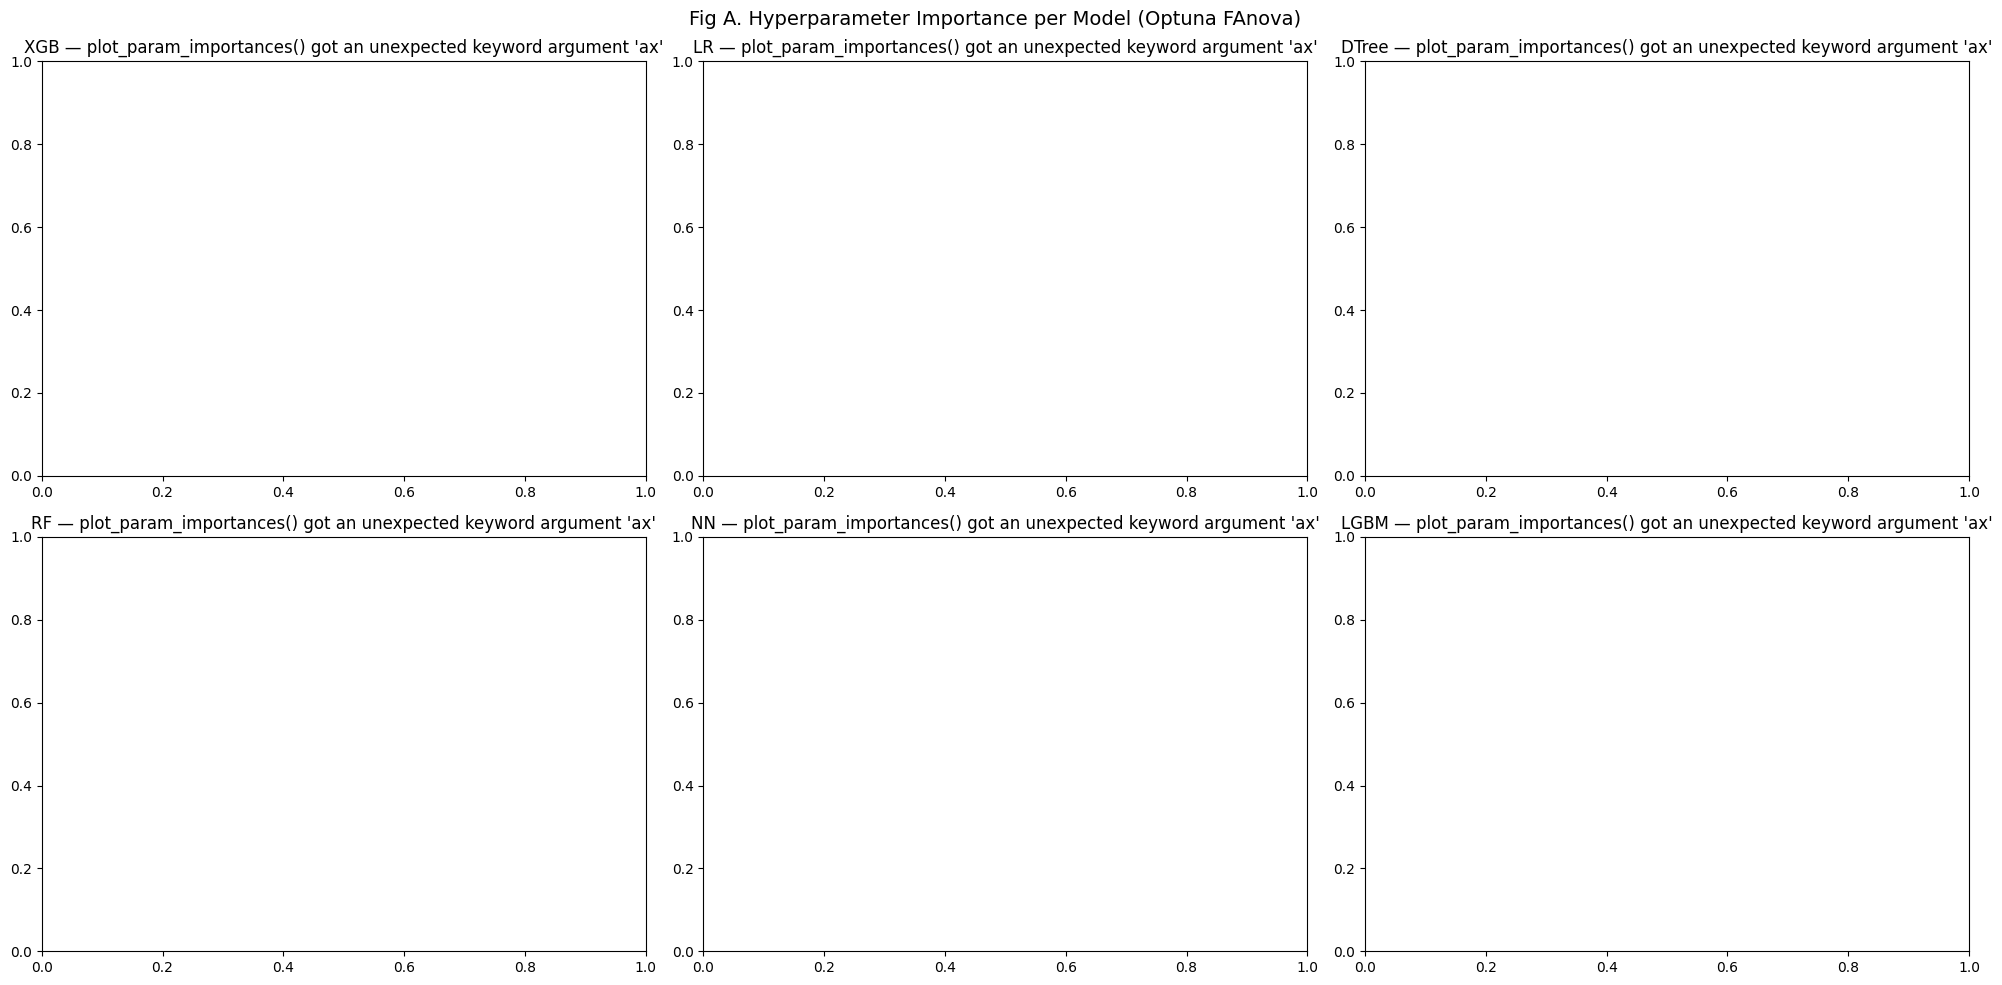

In [24]:
# Fig A: Hyperparameter Importance — which params drove the TRP-fairness objective most
from optuna.visualization.matplotlib import plot_param_importances

studies = {
    'XGB': study_xgb, 'LR': study_lr, 'DTree': study_dt,
    'RF': study_rf, 'NN': study_nn, 'LGBM': study_lgbm
}

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Fig A. Hyperparameter Importance per Model (Optuna FAnova)', fontsize=14)
for ax, (name, study) in zip(axes.flat, studies.items()):
    try:
        plot_param_importances(study, ax=ax)
        ax.set_title(name, fontsize=11)
    except Exception as e:
        ax.set_title(f'{name} — {e}')
plt.tight_layout()
plt.savefig('/content/figA_hp_importance.png', dpi=150)
plt.show()

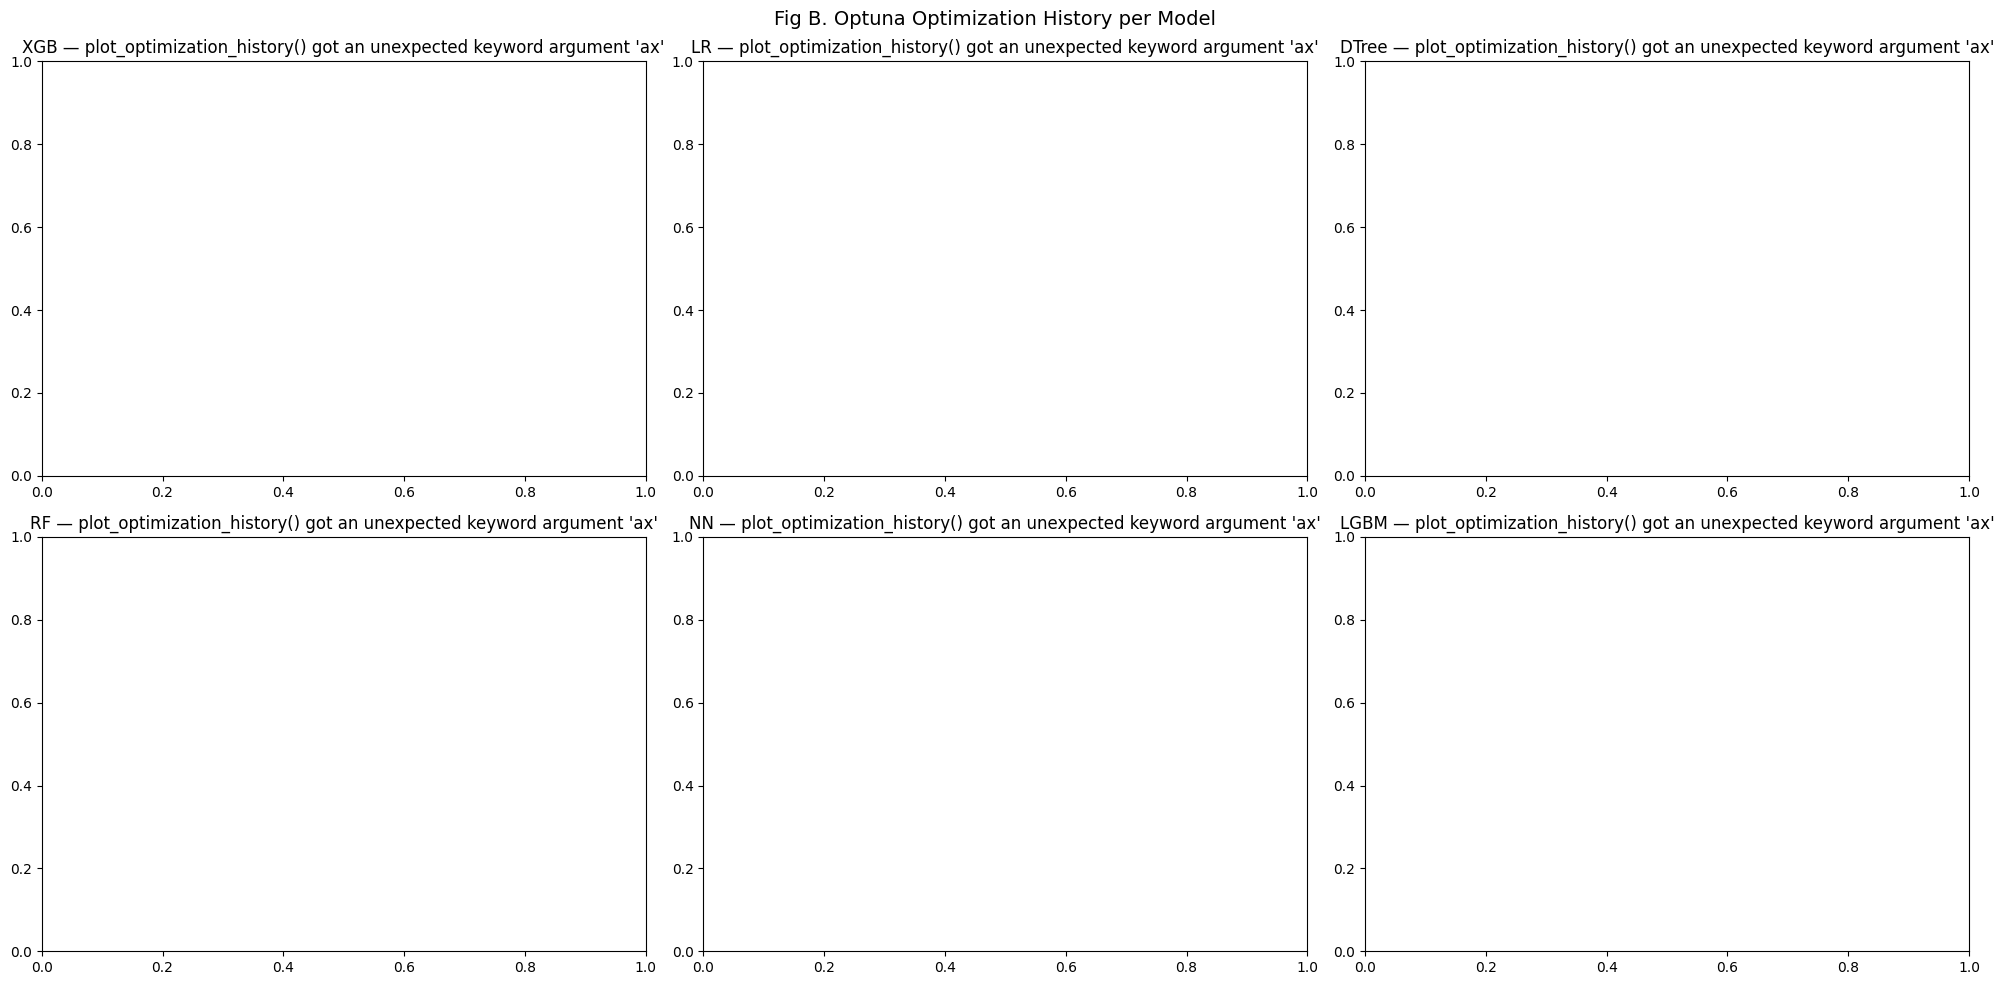

In [25]:
# Fig B: Optimization History — how the best objective improved over Optuna trials
from optuna.visualization.matplotlib import plot_optimization_history

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Fig B. Optuna Optimization History per Model', fontsize=14)
for ax, (name, study) in zip(axes.flat, studies.items()):
    try:
        plot_optimization_history(study, ax=ax)
        ax.set_title(name, fontsize=11)
    except Exception as e:
        ax.set_title(f'{name} — {e}')
plt.tight_layout()
plt.savefig('/content/figB_optuna_history.png', dpi=150)
plt.show()

XGB slice plot error: 'numpy.ndarray' object has no attribute 'suptitle'
LR slice plot error: 'numpy.ndarray' object has no attribute 'suptitle'
DTree slice plot error: 'numpy.ndarray' object has no attribute 'suptitle'
RF slice plot error: 'numpy.ndarray' object has no attribute 'suptitle'
NN slice plot error: 'numpy.ndarray' object has no attribute 'suptitle'
LGBM slice plot error: 'numpy.ndarray' object has no attribute 'suptitle'


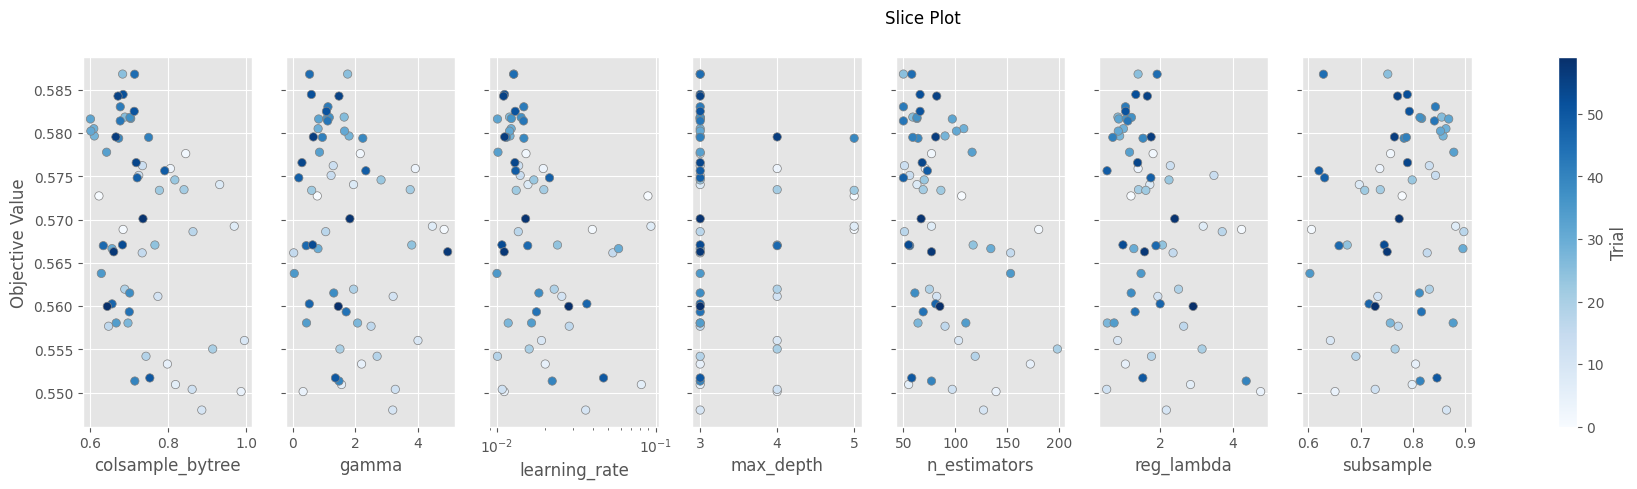

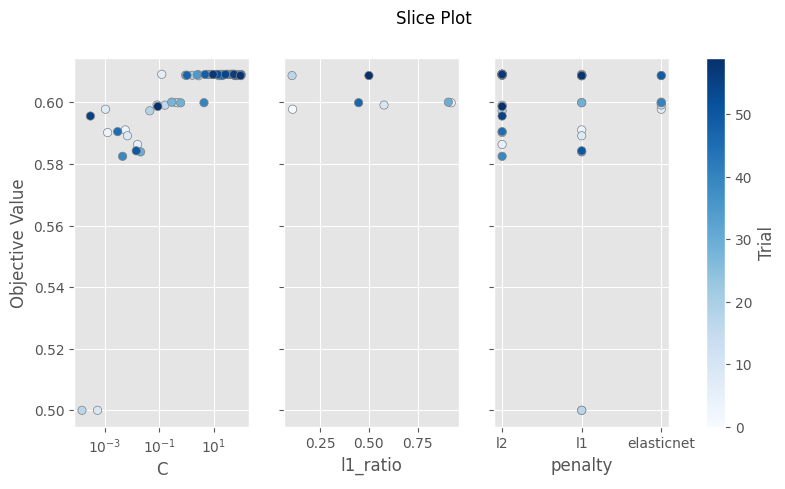

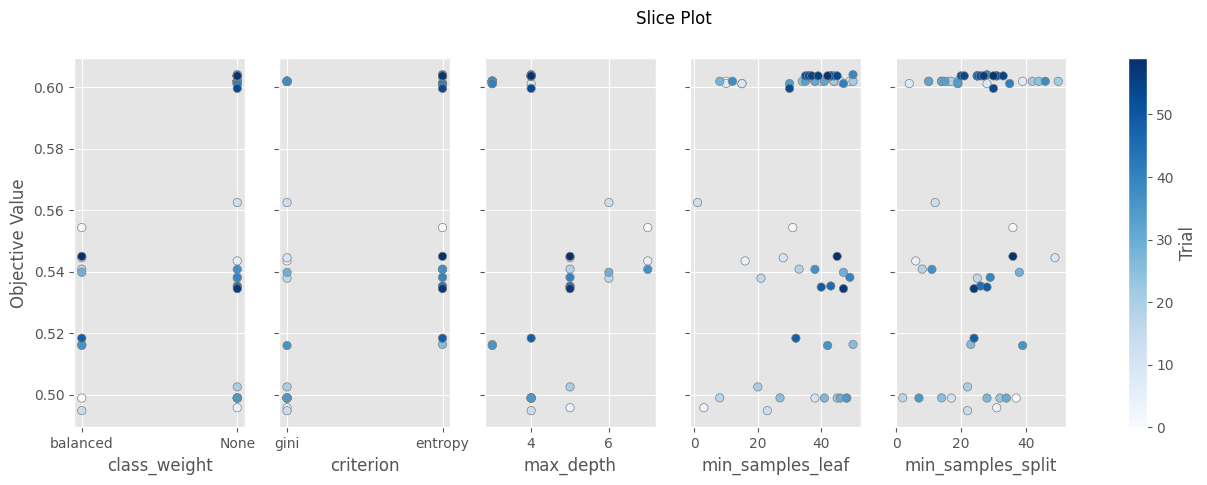

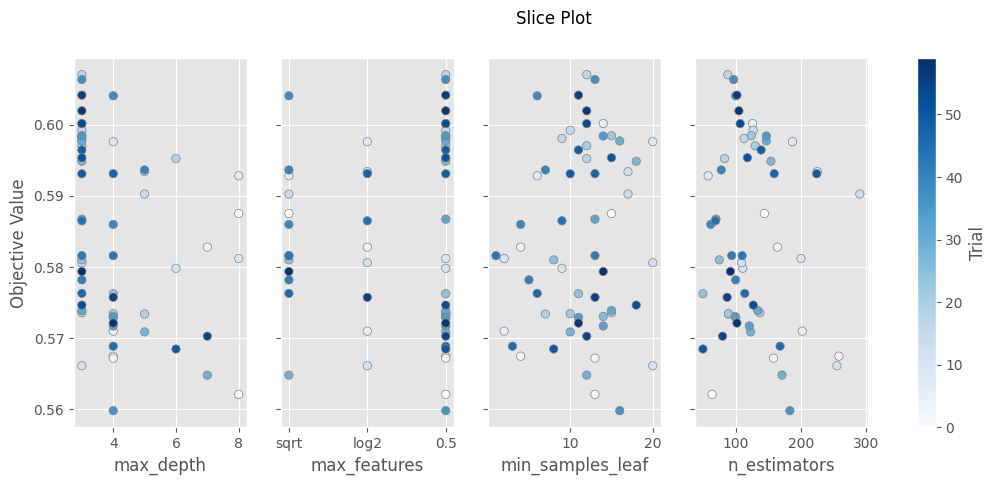

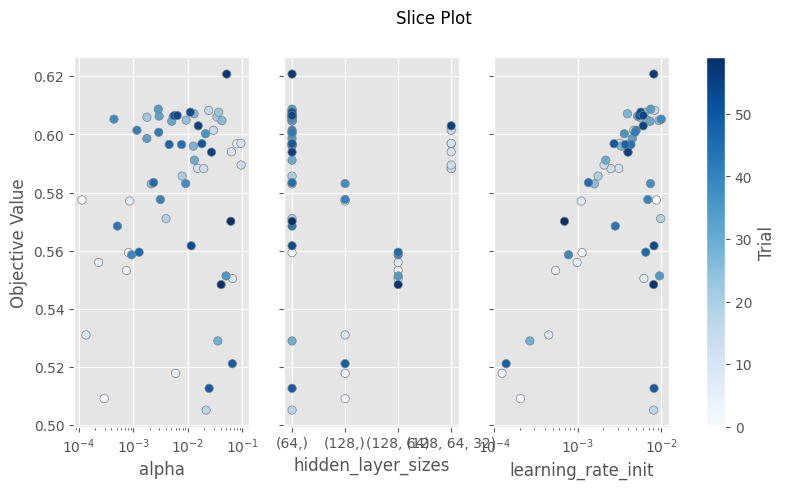

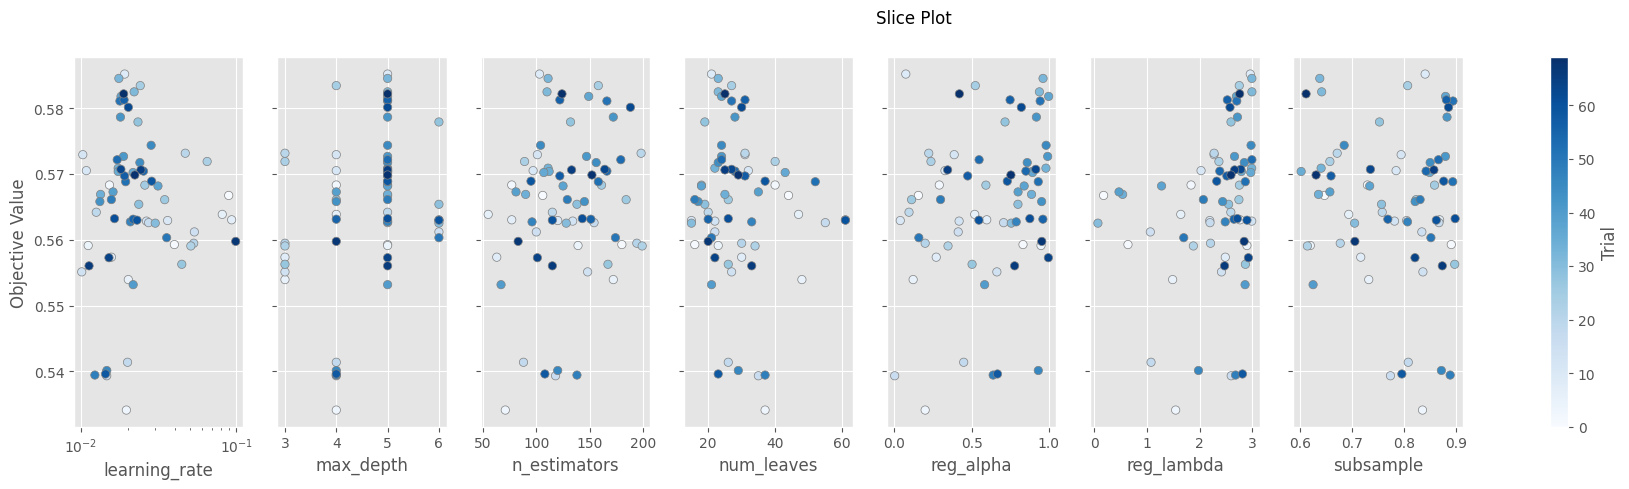

In [26]:
# Fig C: Slice Plots — individual parameter vs objective (others held at best values)
from optuna.visualization.matplotlib import plot_slice

for name, study in studies.items():
    try:
        fig = plot_slice(study)
        fig.suptitle(f'Fig C. Slice Plot — {name}', fontsize=12, y=1.01)
        plt.tight_layout()
        plt.savefig(f'/content/figC_slice_{name.lower()}.png', dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'{name} slice plot error: {e}')

## 4. Combine All Results

In [27]:
all_results = {}
all_results.update(xgb_results)
all_results.update(lr_results)
all_results.update(dt_results)
all_results.update(rf_results)
all_results.update(nn_results)
all_results.update(lgbm_results)
print(f'Total model configs: {len(all_results)}')

print_selection_table(all_results, sort_key='val_auc',  reverse=True,  title='All Models — Val AUC')
print_selection_table(all_results, sort_key='val_trp',  reverse=True,  title='All Models — Val TRP (higher = more robust)')
print_selection_table(all_results, sort_key='auc_drop', reverse=False, title='All Models — Classic AUC Drop (lower = more robust)')
print_selection_table(all_results, sort_key='val_f1',   reverse=True,  title='All Models — Val F1')

Total model configs: 30

=== All Models — Val AUC ===
XGB_optuna_2                    val_AUC=0.6831  test_AUC=0.6841  rand_AUC=0.6999  drop=0.0158  val_TRP=0.6654  val_F1=0.3787
XGB_optuna_4                    val_AUC=0.6829  test_AUC=0.6837  rand_AUC=0.7003  drop=0.0166  val_TRP=0.6651  val_F1=0.3793
XGB_optuna_3                    val_AUC=0.6822  test_AUC=0.6829  rand_AUC=0.6995  drop=0.0166  val_TRP=0.6649  val_F1=0.3776
XGB_optuna_1                    val_AUC=0.6819  test_AUC=0.6831  rand_AUC=0.6988  drop=0.0156  val_TRP=0.6648  val_F1=0.3777
RF_optuna_5                     val_AUC=0.6816  test_AUC=0.6836  rand_AUC=0.6943  drop=0.0108  val_TRP=0.6633  val_F1=0.3788
RF_optuna_3                     val_AUC=0.6816  test_AUC=0.6835  rand_AUC=0.6943  drop=0.0107  val_TRP=0.6633  val_F1=0.3789
RF_optuna_2                     val_AUC=0.6816  test_AUC=0.6835  rand_AUC=0.6943  drop=0.0108  val_TRP=0.6635  val_F1=0.3793
RF_optuna_1                     val_AUC=0.6815  test_AUC=0.6834  rand_A

## 5. Fairness Analysis — Validation Set

Threshold sweep 0.1–0.9 for full stress-test. Group-wise AUC restored from prefinal.

In [28]:
fairness_val = {}
for name in all_results:
    yp  = all_results[name]['temporal']['val_y_prob']
    thr = all_results[name]['temporal']['threshold']
    fairness_val[name] = {
        'credit':       compute_group_metrics_at_threshold(y_val_t,yp,['short','mid','long'],val_t['credit_group'],thr),
        'income':       compute_group_metrics_at_threshold(y_val_t,yp,['low','mid','high'],val_t['income_group'],thr),
        'credit_sweep': compute_threshold_sweep(y_val_t,yp,['short','mid','long'],val_t['credit_group'],FAIRNESS_THRESHOLDS),
        'income_sweep': compute_threshold_sweep(y_val_t,yp,['low','mid','high'],val_t['income_group'],FAIRNESS_THRESHOLDS),
    }
print(f'Fairness computed for {len(fairness_val)} models. Thresholds: {FAIRNESS_THRESHOLDS}')

Fairness computed for 30 models. Thresholds: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]


In [29]:
rows = []
for name in all_results:
    res = all_results[name]
    cf  = fairness_val[name]['credit'];   inf = fairness_val[name]['income']
    csw = fairness_val[name]['credit_sweep']; isw = fairness_val[name]['income_sweep']
    rows.append({
        'Model':                 name,
        'Val AUC':               round(res['temporal']['val_auc'],4),
        'Val TRP':               round(res['val_trp'],4),
        'Val F1':                round(res['temporal']['val_f1'],4),
        'Val Acc':               round(res['temporal']['val_acc'],4),
        'Random Test AUC':       round(res['random']['auc'],4),
        'Val PR-AUC':            round(res['temporal']['val_pr_auc'],4),
        'AUC Drop (classic)':    round(res['auc_drop_classic'],4),
        'Credit AUC_disp':       round(cf['AUC'].max()-cf['AUC'].min(),4),
        'Income AUC_disp':       round(inf['AUC'].max()-inf['AUC'].min(),4),
        'Worst Credit FPR_disp': round(csw['FPR_disp'].max(),4),
        'Worst Credit TPR_disp': round(csw['TPR_disp'].max(),4),
        'Worst Credit PPR_disp': round(csw['PPR_disp'].max(),4),
        'Worst Income FPR_disp': round(isw['FPR_disp'].max(),4),
        'Worst Income TPR_disp': round(isw['TPR_disp'].max(),4),
        'Worst Income PPR_disp': round(isw['PPR_disp'].max(),4),
    })
df_fairness_val = pd.DataFrame(rows).sort_values('Val AUC', ascending=False)
print('\n=== Validation Fairness Summary ===')
print(df_fairness_val.to_string(index=False))


=== Validation Fairness Summary ===
         Model  Val AUC  Val TRP  Val F1  Val Acc  Random Test AUC  Val PR-AUC  AUC Drop (classic)  Credit AUC_disp  Income AUC_disp  Worst Credit FPR_disp  Worst Credit TPR_disp  Worst Credit PPR_disp  Worst Income FPR_disp  Worst Income TPR_disp  Worst Income PPR_disp
  XGB_optuna_2   0.6831   0.6654  0.3787   0.6737           0.6999      0.3094              0.0158           0.0234           0.0445                 0.0371                 0.0538                 0.0467                 0.0892                 0.1532                 0.1083
  XGB_optuna_4   0.6829   0.6651  0.3793   0.6687           0.7003      0.3085              0.0166           0.0235           0.0449                 0.0385                 0.0463                 0.0469                 0.0886                 0.1307                 0.1050
  XGB_optuna_3   0.6822   0.6649  0.3776   0.6727           0.6995      0.3076              0.0166           0.0233           0.0438                 0

## 6. Composite Scoring — Model Selection (Validation Set)

All terms min-max normalised so weights are truly comparable (higher = better):

    Final Score = 0.35 × norm(Val TRP ↑)
               + 0.15 × norm(Val AUC ↑)
               + 0.10 × norm(Val Acc ↑)
               − 0.40 × avg(norm(6 fairness disparities ↓))

`AUC Drop (classic)` is reported but **not** used in the composite — it is a descriptive metric for the report.

In [30]:
def minmax(col):
    rng = col.max() - col.min()
    return (col - col.min()) / (rng + 1e-9)

df_sc = df_fairness_val.copy()

df_sc['_trp_n'] = minmax(df_sc['Val TRP'])
df_sc['_auc_n'] = minmax(df_sc['Val AUC'])
df_sc['_acc_n'] = minmax(df_sc['Val Acc'])

# All 6 fairness disparities, equally weighted
df_sc['_cf_fpr'] = minmax(df_sc['Worst Credit FPR_disp'])
df_sc['_cf_tpr'] = minmax(df_sc['Worst Credit TPR_disp'])
df_sc['_cf_ppr'] = minmax(df_sc['Worst Credit PPR_disp'])
df_sc['_if_fpr'] = minmax(df_sc['Worst Income FPR_disp'])
df_sc['_if_tpr'] = minmax(df_sc['Worst Income TPR_disp'])
df_sc['_if_ppr'] = minmax(df_sc['Worst Income PPR_disp'])

df_sc['_fair_n'] = (df_sc['_cf_fpr']+df_sc['_cf_tpr']+df_sc['_cf_ppr']+
                    df_sc['_if_fpr']+df_sc['_if_tpr']+df_sc['_if_ppr']) / 6

df_sc['Final Score'] = (0.35*df_sc['_trp_n'] + 0.15*df_sc['_auc_n'] +
                         0.10*df_sc['_acc_n'] - 0.40*df_sc['_fair_n']).round(4)

df_ranked_val = df_sc[['Model','Final Score','Val TRP','Val AUC','Val PR-AUC','Val F1','Val Acc',
                        'AUC Drop (classic)','Random Test AUC',
                        'Credit AUC_disp','Income AUC_disp',
                        'Worst Credit FPR_disp','Worst Income FPR_disp',
                        'Worst Credit TPR_disp','Worst Income TPR_disp',
                        'Worst Credit PPR_disp','Worst Income PPR_disp',
                        '_fair_n']].sort_values('Final Score',ascending=False).reset_index(drop=True)

print('=== Composite Ranking — Validation Set (higher = better) ===')
print(df_ranked_val.to_string(index=False))
print(f'\n★ Best Overall: {df_ranked_val.iloc[0]["Model"]}')

=== Composite Ranking — Validation Set (higher = better) ===
         Model  Final Score  Val TRP  Val AUC  Val PR-AUC  Val F1  Val Acc  AUC Drop (classic)  Random Test AUC  Credit AUC_disp  Income AUC_disp  Worst Credit FPR_disp  Worst Income FPR_disp  Worst Credit TPR_disp  Worst Income TPR_disp  Worst Credit PPR_disp  Worst Income PPR_disp  _fair_n
  XGB_optuna_1       0.4753   0.6648   0.6819      0.3088  0.3777   0.6757              0.0156           0.6988           0.0236           0.0438                 0.0212                 0.0615                 0.0420                 0.1228                 0.0299                 0.0780 0.035898
  XGB_optuna_5       0.4518   0.6647   0.6813      0.3070  0.3786   0.6723              0.0175           0.6995           0.0234           0.0447                 0.0284                 0.0683                 0.0390                 0.1316                 0.0360                 0.0833 0.063252
  XGB_optuna_4       0.4397   0.6651   0.6829      0.3085  0

In [31]:
# Select best per family
MODEL_PREFIXES = {'XGB':'XGB_','LR':'LR_','DTree':'DTree_','RF':'RF_','NN':'NN_','LGBM':'LGBM_'}

best_per_model = {}
for label, prefix in MODEL_PREFIXES.items():
    cands = df_ranked_val[df_ranked_val['Model'].str.startswith(prefix)]
    if cands.empty: continue
    best_name = cands.iloc[0]['Model']
    best_per_model[best_name] = all_results[best_name]
    print(f'{label:6s} → {best_name}  (Final Score={cands.iloc[0]["Final Score"]:.4f})')
print(f'\nSelected {len(best_per_model)} representative models for test evaluation.')

XGB    → XGB_optuna_1  (Final Score=0.4753)
LR     → LR_optuna_1  (Final Score=0.2058)
DTree  → DTree_optuna_2  (Final Score=-0.1822)
RF     → RF_optuna_4  (Final Score=0.3037)
NN     → NN_optuna_1  (Final Score=0.2013)
LGBM   → LGBM_optuna_3  (Final Score=0.2060)

Selected 6 representative models for test evaluation.


## 7. Test Set Evaluation — Best Model Per Family

Model selection is now locked. Test set is touched for the first time here.

In [32]:
test_fairness = {}
test_meta = test_t.copy()

for name in best_per_model:
    yp  = best_per_model[name]['temporal']['y_prob']
    thr = best_per_model[name]['temporal']['threshold']
    test_fairness[name] = {
        'credit':       compute_group_metrics_at_threshold(y_test_t,yp,['short','mid','long'],test_meta['credit_group'],thr),
        'income':       compute_group_metrics_at_threshold(y_test_t,yp,['low','mid','high'],test_meta['income_group'],thr),
        'credit_sweep': compute_threshold_sweep(y_test_t,yp,['short','mid','long'],test_meta['credit_group'],FAIRNESS_THRESHOLDS),
        'income_sweep': compute_threshold_sweep(y_test_t,yp,['low','mid','high'],test_meta['income_group'],FAIRNESS_THRESHOLDS),
    }
print('Test fairness done for:', list(test_fairness.keys()))

Test fairness done for: ['XGB_optuna_1', 'LR_optuna_1', 'DTree_optuna_2', 'RF_optuna_4', 'NN_optuna_1', 'LGBM_optuna_3']


In [33]:
rows_te = []
for name in best_per_model:
    res = best_per_model[name]
    cf  = test_fairness[name]['credit'];  inf = test_fairness[name]['income']
    csw = test_fairness[name]['credit_sweep']; isw = test_fairness[name]['income_sweep']
    rows_te.append({
        'Model':                  name,
        'Temporal Test AUC':      round(res['temporal']['auc'],4),
        'Random Test AUC':        round(res['random']['auc'],4),
        'AUC Drop (classic)':     round(res['auc_drop_classic'],4),
        'Test TRP':               round(res['test_trp'],4),
        'Test F1':                round(res['temporal']['f1'],4),
        'Test Acc':               round(res['temporal']['acc'],4),
        'Test Brier':             round(res['temporal']['brier'],4),
        'Test PR-AUC':            round(res['temporal']['pr_auc'],4),
        'Credit AUC_disp':        round(cf['AUC'].max()-cf['AUC'].min(),4),
        'Income AUC_disp':        round(inf['AUC'].max()-inf['AUC'].min(),4),
        'Worst Credit FPR_disp':  round(csw['FPR_disp'].max(),4),
        'Worst Credit TPR_disp':  round(csw['TPR_disp'].max(),4),
        'Worst Credit PPR_disp':  round(csw['PPR_disp'].max(),4),
        'Worst Income FPR_disp':  round(isw['FPR_disp'].max(),4),
        'Worst Income TPR_disp':  round(isw['TPR_disp'].max(),4),
        'Worst Income PPR_disp':  round(isw['PPR_disp'].max(),4),
    })

df_test = pd.DataFrame(rows_te)
df_ts = df_test.copy()
df_ts['_trp_n'] = minmax(df_ts['Test TRP'])
df_ts['_auc_n'] = minmax(df_ts['Temporal Test AUC'])
df_ts['_acc_n'] = minmax(df_ts['Test Acc'])
df_ts['_cf_fpr'] = minmax(df_ts['Worst Credit FPR_disp'])
df_ts['_cf_tpr'] = minmax(df_ts['Worst Credit TPR_disp'])
df_ts['_cf_ppr'] = minmax(df_ts['Worst Credit PPR_disp'])
df_ts['_if_fpr'] = minmax(df_ts['Worst Income FPR_disp'])
df_ts['_if_tpr'] = minmax(df_ts['Worst Income TPR_disp'])
df_ts['_if_ppr'] = minmax(df_ts['Worst Income PPR_disp'])
df_ts['_fair_n'] = (df_ts['_cf_fpr']+df_ts['_cf_tpr']+df_ts['_cf_ppr']+
                    df_ts['_if_fpr']+df_ts['_if_tpr']+df_ts['_if_ppr']) / 6
df_ts['Test Final Score'] = (0.35*df_ts['_trp_n']+0.15*df_ts['_auc_n']+
                              0.10*df_ts['_acc_n']-0.40*df_ts['_fair_n']).round(4)

df_ranked_test = df_ts[['Model','Test Final Score','Temporal Test AUC','Random Test AUC',
                          'AUC Drop (classic)','Test TRP','Test F1','Test Acc','Test Brier','Test PR-AUC',
                          'Credit AUC_disp','Income AUC_disp',
                          'Worst Credit FPR_disp','Worst Income FPR_disp',
                          'Worst Credit TPR_disp','Worst Income TPR_disp',
                          'Worst Credit PPR_disp','Worst Income PPR_disp',
                          '_fair_n']].sort_values('Test Final Score',ascending=False).reset_index(drop=True)

print('=== Final Test Set Results ===')
print(df_ranked_test.to_string(index=False))
print(f'\n★ Best Overall (Test): {df_ranked_test.iloc[0]["Model"]}')

=== Final Test Set Results ===
         Model  Test Final Score  Temporal Test AUC  Random Test AUC  AUC Drop (classic)  Test TRP  Test F1  Test Acc  Test Brier  Test PR-AUC  Credit AUC_disp  Income AUC_disp  Worst Credit FPR_disp  Worst Income FPR_disp  Worst Credit TPR_disp  Worst Income TPR_disp  Worst Credit PPR_disp  Worst Income PPR_disp  _fair_n
  XGB_optuna_1            0.5964             0.6831           0.6988              0.0156    0.6770   0.3006    0.6965      0.1048       0.2225           0.0212           0.0314                 0.0216                 0.0596                 0.0296                 0.1067                 0.0264                 0.0692 0.000000
   RF_optuna_4            0.3507             0.6796           0.6953              0.0156    0.6752   0.3004    0.6986      0.1036       0.2187           0.0212           0.0280                 0.0784                 0.1772                 0.0639                 0.1117                 0.0751                 0.1677 0.3530

## 8. Ablation Study — Regularization Strength vs Robustness & Fairness

For LR, XGBoost, and RF: fix best Optuna params, sweep one key regularization parameter.
Shows how regularization strength affects the robustness-fairness tradeoff (required for final report).

In [34]:
def run_ablation(model_fn, param_name, param_values, input_type='scaled', label='Model'):
    """
    Trains a temporal-only model for each param value.
    Returns DataFrame of Val AUC, Val TRP, and worst-case fairness disparity.
    """
    rows = []
    for val in param_values:
        model = model_fn(val)
        Xtr = X_train_t_sc if input_type=='scaled' else X_train_t
        Xva = X_val_t_sc   if input_type=='scaled' else X_val_t
        model.fit(Xtr, y_train_t)

        yearly_aucs = {}
        for yr,(X_yr,y_yr,X_yr_sc,_) in yearly_tests.items():
            X_in = X_yr_sc if input_type=='scaled' else X_yr
            yearly_aucs[yr] = roc_auc_score(y_yr, model.predict_proba(X_in)[:,1])

        val_trp = compute_trp(yearly_aucs, VAL_YEARS)
        yp_val  = model.predict_proba(Xva)[:,1]
        val_auc = roc_auc_score(y_val_t, yp_val)
        best_thr = max(np.arange(0.05,0.95,0.01),
                       key=lambda t: f1_score(y_val_t,(yp_val>=t).astype(int),zero_division=0))

        csw = compute_threshold_sweep(y_val_t,yp_val,['short','mid','long'],val_t['credit_group'],FAIRNESS_THRESHOLDS)
        isw = compute_threshold_sweep(y_val_t,yp_val,['low','mid','high'],val_t['income_group'],FAIRNESS_THRESHOLDS)

        rows.append({
            param_name:  val,
            'Val AUC':   round(val_auc,4),
            'Val TRP':   round(val_trp,4),
            'Worst FPR': round(max(csw['FPR_disp'].max(), isw['FPR_disp'].max()),4),
            'Worst TPR': round(max(csw['TPR_disp'].max(), isw['TPR_disp'].max()),4),
            'Worst PPR': round(max(csw['PPR_disp'].max(), isw['PPR_disp'].max()),4),
            'Threshold': round(best_thr,2),
        })
        print(f'  {label} {param_name}={val}  AUC={val_auc:.4f}  TRP={val_trp:.4f}  FPR_disp={rows[-1]["Worst FPR"]:.4f}')
    return pd.DataFrame(rows)

In [35]:
# LR — C sweep (strong→weak regularization)
best_lr_p   = study_lr.best_params.copy()
best_lr_pen = best_lr_p.get('penalty','l2')
best_lr_l1r = best_lr_p.get('l1_ratio', None)
best_lr_sol = 'saga' if best_lr_pen in ('elasticnet','l1') else 'lbfgs'

def make_lr_ablation(c):
    kw = dict(C=c, penalty=best_lr_pen, solver=best_lr_sol,
              max_iter=2000, random_state=42)
    if best_lr_l1r is not None: kw['l1_ratio'] = best_lr_l1r
    return LogisticRegression(**kw)

print('=== Ablation: LR — C sweep (lower C = stronger regularization) ===')
df_ablation_lr = run_ablation(make_lr_ablation,'C',[0.0001,0.001,0.01,0.1,1.0,10.0,100.0],label='LR')
print('\nLR Ablation:')
print(df_ablation_lr.to_string(index=False))

=== Ablation: LR — C sweep (lower C = stronger regularization) ===
  LR C=0.0001  AUC=0.5000  TRP=0.5000  FPR_disp=0.0000
  LR C=0.001  AUC=0.6774  TRP=0.6519  FPR_disp=0.0143
  LR C=0.01  AUC=0.6820  TRP=0.6615  FPR_disp=0.2919
  LR C=0.1  AUC=0.6798  TRP=0.6694  FPR_disp=0.3266
  LR C=1.0  AUC=0.6781  TRP=0.6691  FPR_disp=0.3339
  LR C=10.0  AUC=0.6779  TRP=0.6691  FPR_disp=0.3341
  LR C=100.0  AUC=0.6779  TRP=0.6691  FPR_disp=0.3342

LR Ablation:
       C  Val AUC  Val TRP  Worst FPR  Worst TPR  Worst PPR  Threshold
  0.0001   0.5000   0.5000     0.0000     0.0000     0.0000       0.05
  0.0010   0.6774   0.6519     0.0143     0.0338     0.0202       0.15
  0.0100   0.6820   0.6615     0.2919     0.1506     0.2777       0.15
  0.1000   0.6798   0.6694     0.3266     0.1803     0.3109       0.16
  1.0000   0.6781   0.6691     0.3339     0.1851     0.3178       0.17
 10.0000   0.6779   0.6691     0.3341     0.1864     0.3181       0.16
100.0000   0.6779   0.6691     0.3342     0.1864 

In [36]:
# XGBoost — subsample sweep (fraction of training rows per tree)
# reg_lambda was insensitive (AUC varied only 0.0003 across 0.1-10).
# subsample controls row-level sampling and shows clearer regularization effect.
best_xgb_p = {k:v for k,v in study_xgb.best_params.items() if k != 'subsample'}

def make_xgb_ablation(ss):
    return XGBClassifier(**best_xgb_p, subsample=ss, eval_metric='logloss', random_state=42)

print('=== Ablation: XGBoost — subsample sweep (lower = more regularized) ===')
df_ablation_xgb = run_ablation(make_xgb_ablation,'subsample',[0.4,0.5,0.6,0.7,0.8,0.9,1.0],label='XGB')
print()
print(df_ablation_xgb.to_string(index=False))

=== Ablation: XGBoost — subsample sweep (lower = more regularized) ===
  XGB subsample=0.4  AUC=0.6832  TRP=0.6643  FPR_disp=0.0668
  XGB subsample=0.5  AUC=0.6831  TRP=0.6642  FPR_disp=0.0729
  XGB subsample=0.6  AUC=0.6835  TRP=0.6656  FPR_disp=0.0716
  XGB subsample=0.7  AUC=0.6828  TRP=0.6653  FPR_disp=0.0687
  XGB subsample=0.8  AUC=0.6820  TRP=0.6642  FPR_disp=0.0600
  XGB subsample=0.9  AUC=0.6811  TRP=0.6646  FPR_disp=0.0612
  XGB subsample=1.0  AUC=0.6810  TRP=0.6634  FPR_disp=0.0432

 subsample  Val AUC  Val TRP  Worst FPR  Worst TPR  Worst PPR  Threshold
       0.4   0.6832   0.6643     0.0668     0.1314     0.0843       0.16
       0.5   0.6831   0.6642     0.0729     0.1474     0.0922       0.15
       0.6   0.6835   0.6656     0.0716     0.1477     0.0914       0.15
       0.7   0.6828   0.6653     0.0687     0.1448     0.0880       0.15
       0.8   0.6820   0.6642     0.0600     0.1221     0.0766       0.15
       0.9   0.6811   0.6646     0.0612     0.1272     0.0786  

In [37]:
# RF — max_depth sweep (lower = more regularized)
best_rf_p = {k:v for k,v in study_rf.best_params.items() if k != 'max_depth'}

def make_rf_ablation(depth):
    return RandomForestClassifier(**best_rf_p, max_depth=depth, random_state=42, n_jobs=-1)

print('=== Ablation: RF — max_depth sweep (shallower = more regularized) ===')
df_ablation_rf = run_ablation(make_rf_ablation,'max_depth',[3,4,5,6,7,8,10,15],label='RF')
print('\nRF Ablation:')
print(df_ablation_rf.to_string(index=False))

=== Ablation: RF — max_depth sweep (shallower = more regularized) ===
  RF max_depth=3  AUC=0.6815  TRP=0.6634  FPR_disp=0.2500
  RF max_depth=4  AUC=0.6814  TRP=0.6647  FPR_disp=0.3248
  RF max_depth=5  AUC=0.6810  TRP=0.6663  FPR_disp=0.3542
  RF max_depth=6  AUC=0.6808  TRP=0.6662  FPR_disp=0.3266
  RF max_depth=7  AUC=0.6797  TRP=0.6647  FPR_disp=0.3444
  RF max_depth=8  AUC=0.6784  TRP=0.6626  FPR_disp=0.3433
  RF max_depth=10  AUC=0.6749  TRP=0.6618  FPR_disp=0.3327
  RF max_depth=15  AUC=0.6690  TRP=0.6543  FPR_disp=0.3246

RF Ablation:
 max_depth  Val AUC  Val TRP  Worst FPR  Worst TPR  Worst PPR  Threshold
         3   0.6815   0.6634     0.2500     0.1001     0.2317       0.15
         4   0.6814   0.6647     0.3248     0.1531     0.3040       0.15
         5   0.6810   0.6663     0.3542     0.1831     0.3338       0.15
         6   0.6808   0.6662     0.3266     0.1706     0.3094       0.15
         7   0.6797   0.6647     0.3444     0.1836     0.3261       0.16
         8  

## 9. Visualization

In [38]:
# Family helpers
FAMILY_PREFIXES = {'Logistic Regression':['LR_'],'Decision Tree':['DTree_'],
                   'Random Forest':['RF_'],'XGBoost':['XGB_'],
                   'Neural Network':['NN_'],'LightGBM':['LGBM_']}
family_colors = {'Logistic Regression':'#1f77b4','Decision Tree':'#ff7f0e',
                 'Random Forest':'#2ca02c','XGBoost':'#d62728',
                 'Neural Network':'#9467bd','LightGBM':'#8c564b'}
family_order = list(FAMILY_PREFIXES.keys())

def infer_family(m):
    for fam,pfxs in FAMILY_PREFIXES.items():
        if any(m.startswith(p) for p in pfxs): return fam
    return 'Other'

plot_df = df_ranked_test.copy()
plot_df['Family']  = plot_df['Model'].apply(infer_family)
plot_df['Display'] = plot_df['Family']
plot_df = plot_df[plot_df['Family']!='Other'].copy()
print('Representative models for plotting:', plot_df['Model'].tolist())

Representative models for plotting: ['XGB_optuna_1', 'RF_optuna_4', 'LGBM_optuna_3', 'NN_optuna_1', 'LR_optuna_1', 'DTree_optuna_2']


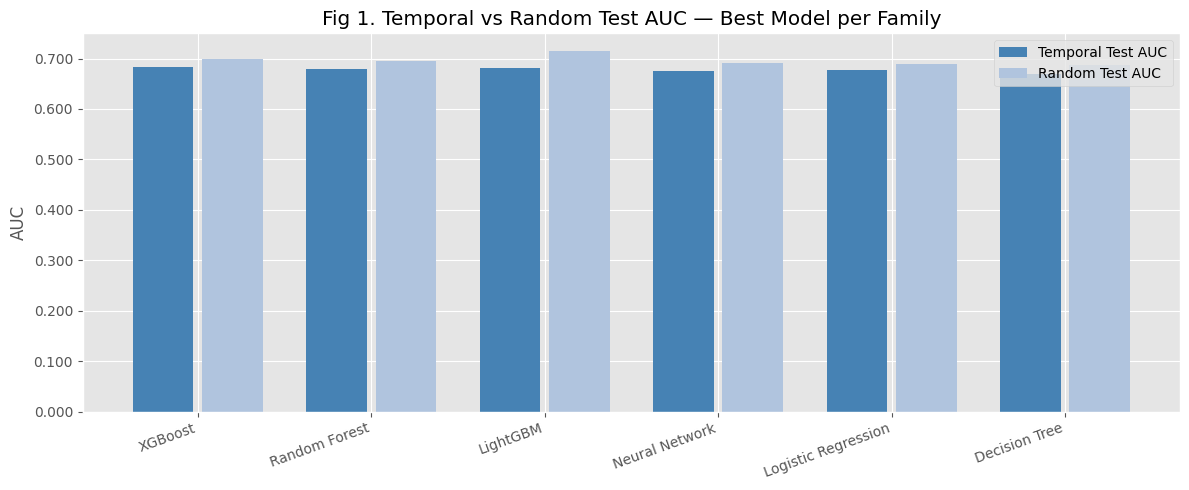

In [39]:
# Fig 1: Temporal vs Random AUC (restored from prefinal — core research question visual)
fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(plot_df))
ax.bar(x-0.2, plot_df['Temporal Test AUC'], 0.35, label='Temporal Test AUC', color='steelblue')
ax.bar(x+0.2, plot_df['Random Test AUC'],   0.35, label='Random Test AUC',   color='lightsteelblue')
ax.set_xticks(x); ax.set_xticklabels(plot_df['Display'], rotation=20, ha='right')
ax.set_ylabel('AUC'); ax.set_title('Fig 1. Temporal vs Random Test AUC — Best Model per Family')
ax.legend(); ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))
plt.tight_layout(); plt.savefig('/content/fig1_temporal_vs_random_auc.png',dpi=150); plt.show()

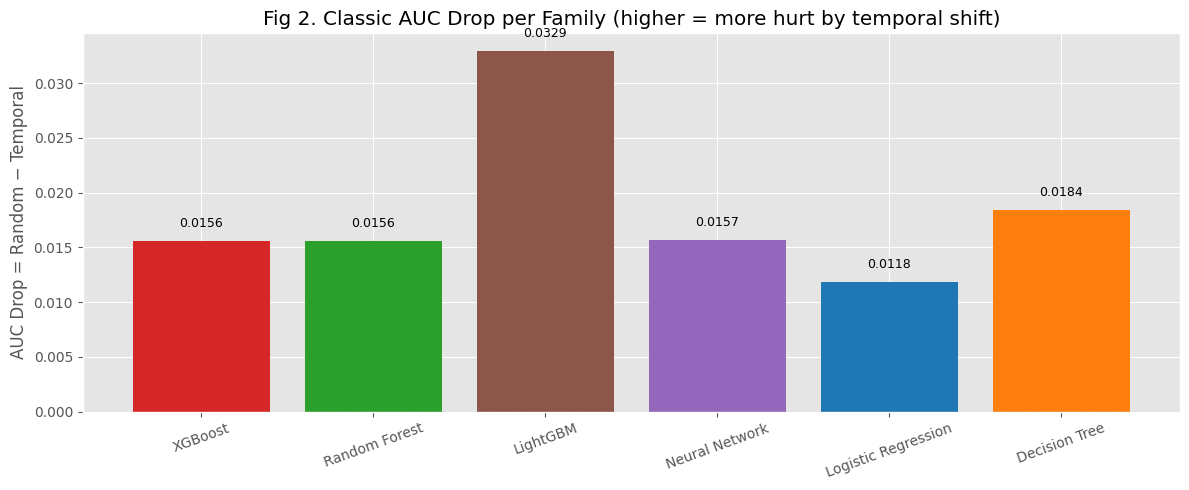

In [40]:
# Fig 2: Classic AUC Drop = Random − Temporal (answers the research question)
fig, ax = plt.subplots(figsize=(12,5))
drops  = plot_df['AUC Drop (classic)'].tolist()
colors = [family_colors.get(f,'#333') for f in plot_df['Family']]
bars   = ax.bar(plot_df['Display'], drops, color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar,v in zip(bars,drops):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('AUC Drop = Random − Temporal'); ax.tick_params(axis='x',rotation=20)
ax.set_title('Fig 2. Classic AUC Drop per Family (higher = more hurt by temporal shift)')
plt.tight_layout(); plt.savefig('/content/fig2_auc_drop_classic.png',dpi=150); plt.show()

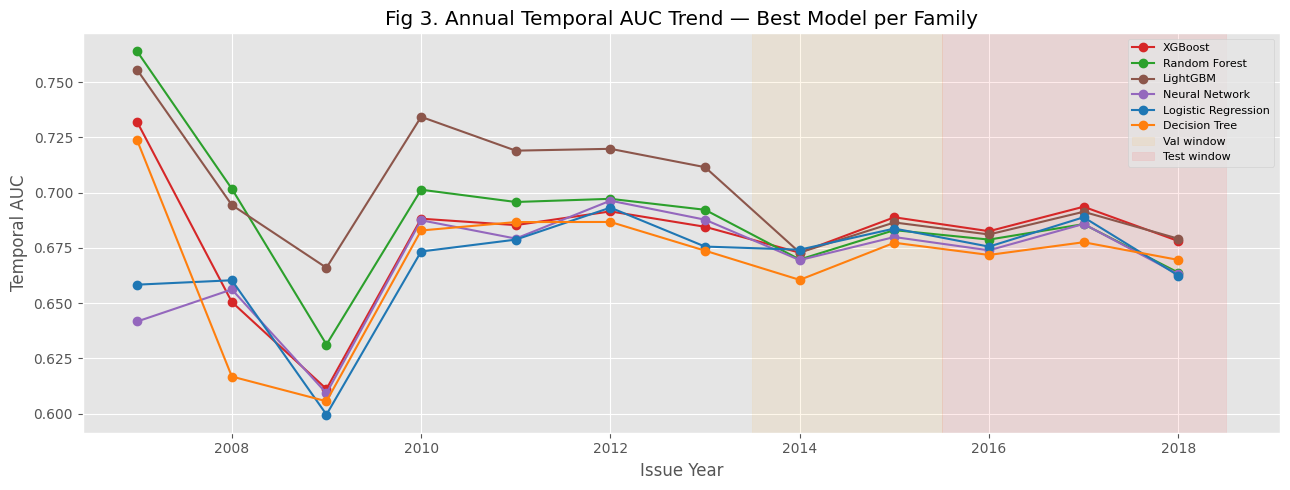

In [41]:
# Fig 3: Yearly Temporal AUC Trend (all years, shaded val/test windows)
fig, ax = plt.subplots(figsize=(13,5))
for mname in plot_df['Model']:
    fam  = infer_family(mname)
    ymap = all_results[mname]['yearly']
    yrs  = sorted(ymap.keys()); vals = [ymap[y] for y in yrs]
    ax.plot(yrs, vals, marker='o', label=fam, color=family_colors[fam])
ax.axvspan(2013.5,2015.5, alpha=0.08, color='orange', label='Val window')
ax.axvspan(2015.5,2018.5, alpha=0.08, color='red',    label='Test window')
ax.set_xlabel('Issue Year'); ax.set_ylabel('Temporal AUC')
ax.set_title('Fig 3. Annual Temporal AUC Trend — Best Model per Family')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('/content/fig3_yearly_auc_trend.png',dpi=150); plt.show()

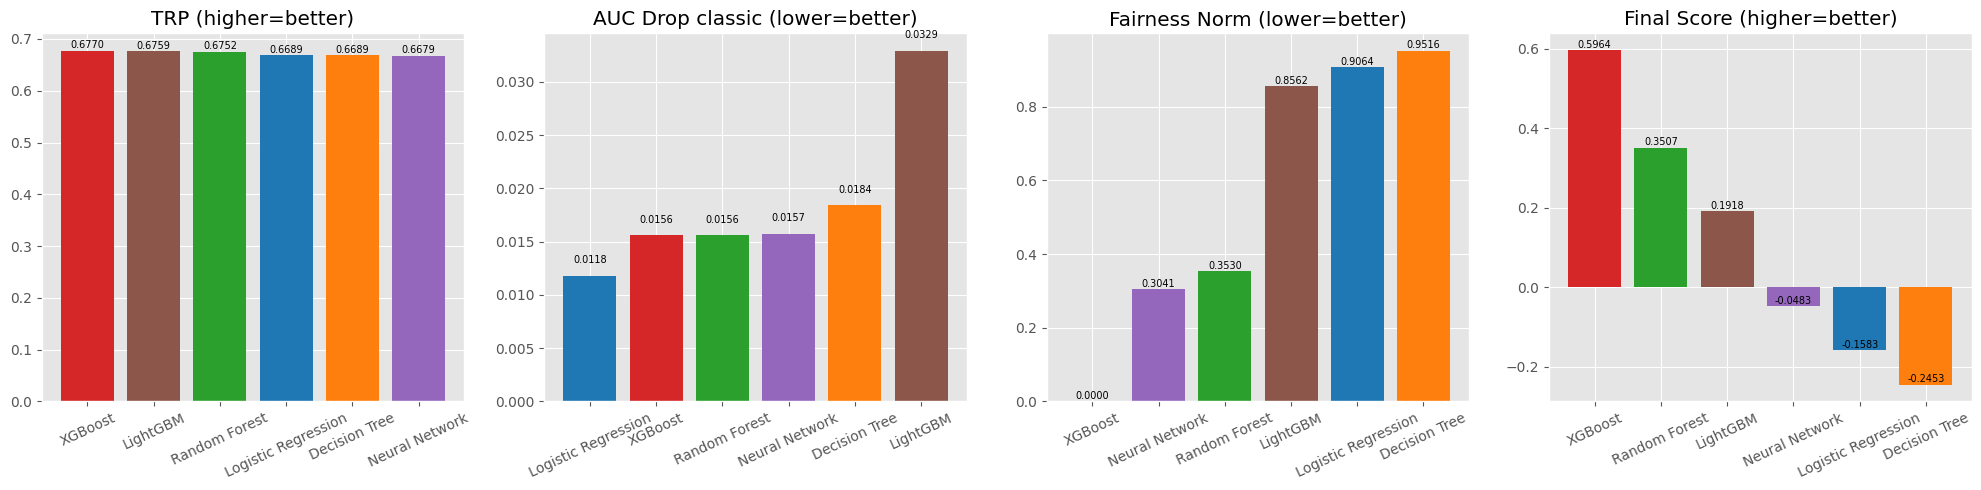

In [42]:
# Fig 4: 4-panel final comparison (TRP / AUC Drop / Fairness / Final Score)
fig, axes = plt.subplots(1,4,figsize=(20,5))
panels = [('Test TRP','TRP (higher=better)',True),
          ('AUC Drop (classic)','AUC Drop classic (lower=better)',False),
          ('_fair_n','Fairness Norm (lower=better)',False),
          ('Test Final Score','Final Score (higher=better)',True)]
for ax,(col,ylabel,rev) in zip(axes,panels):
    sub = df_ranked_test.copy(); sub['Family'] = sub['Model'].apply(infer_family)
    sub = sub[sub['Family']!='Other']
    sub = sub.sort_values(col, ascending=not rev)
    bars = ax.bar(sub['Family'], sub[col], color=[family_colors.get(f,'#999') for f in sub['Family']])
    for bar,v in zip(bars,sub[col]):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.001,f'{v:.4f}',ha='center',va='bottom',fontsize=7)
    ax.set_title(ylabel); ax.tick_params(axis='x',rotation=25)
plt.tight_layout(); plt.savefig('/content/fig4_4panel_comparison.png',dpi=150); plt.show()

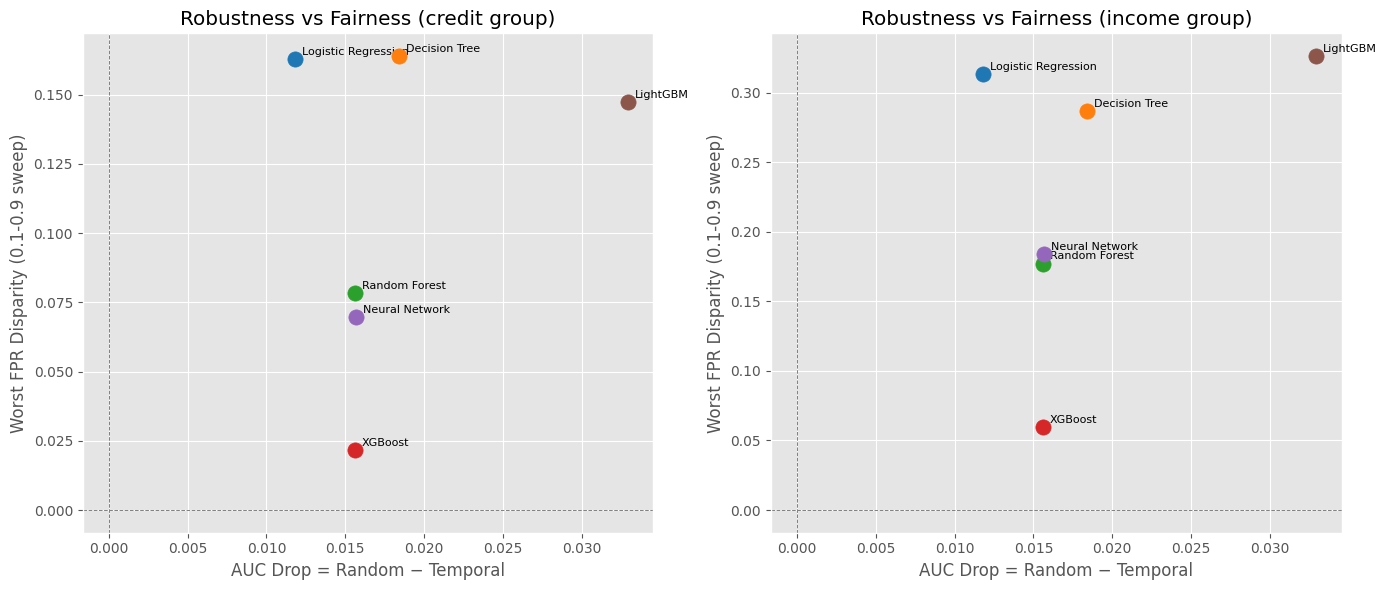

In [43]:
# Fig 5: Robustness vs Fairness scatter (restored from prefinal)
fig, axes = plt.subplots(1,2,figsize=(14,6))
sub = df_ranked_test.copy(); sub['Family'] = sub['Model'].apply(infer_family); sub = sub[sub['Family']!='Other']
for ax,(fair_col,sfx) in zip(axes,[('Worst Credit FPR_disp','credit'),('Worst Income FPR_disp','income')]):
    for _,row in sub.iterrows():
        fam = row['Family']
        ax.scatter(row['AUC Drop (classic)'], row[fair_col], color=family_colors.get(fam,'#999'), s=120, zorder=3)
        ax.annotate(fam,(row['AUC Drop (classic)'],row[fair_col]),textcoords='offset points',xytext=(5,3),fontsize=8)
    ax.set_xlabel('AUC Drop = Random − Temporal'); ax.set_ylabel('Worst FPR Disparity (0.1-0.9 sweep)')
    ax.set_title(f'Robustness vs Fairness ({sfx} group)')
    ax.axhline(0,color='gray',linestyle='--',linewidth=0.7); ax.axvline(0,color='gray',linestyle='--',linewidth=0.7)
plt.tight_layout(); plt.savefig('/content/fig5_robustness_vs_fairness.png',dpi=150); plt.show()

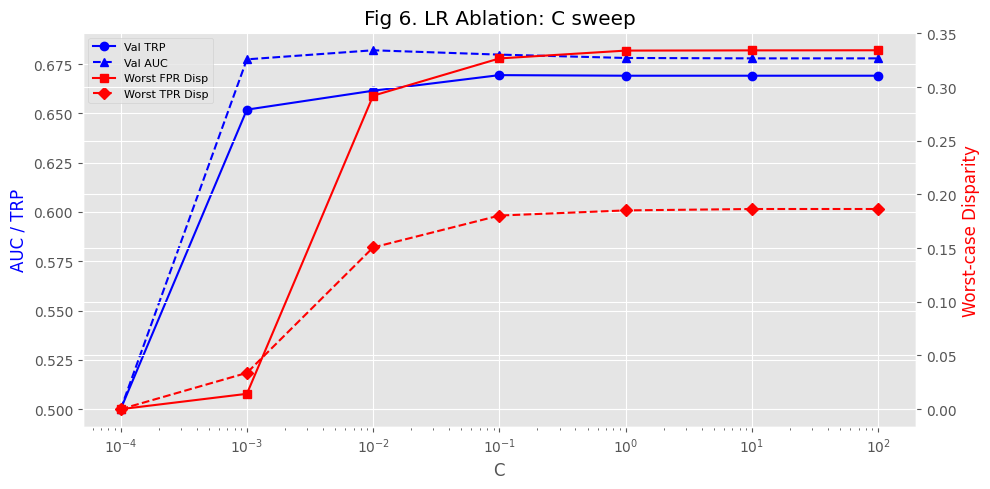

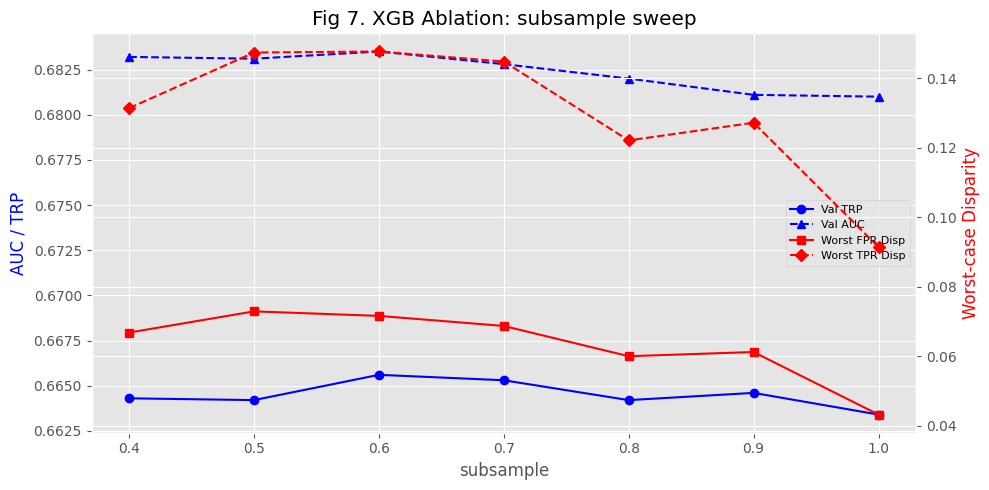

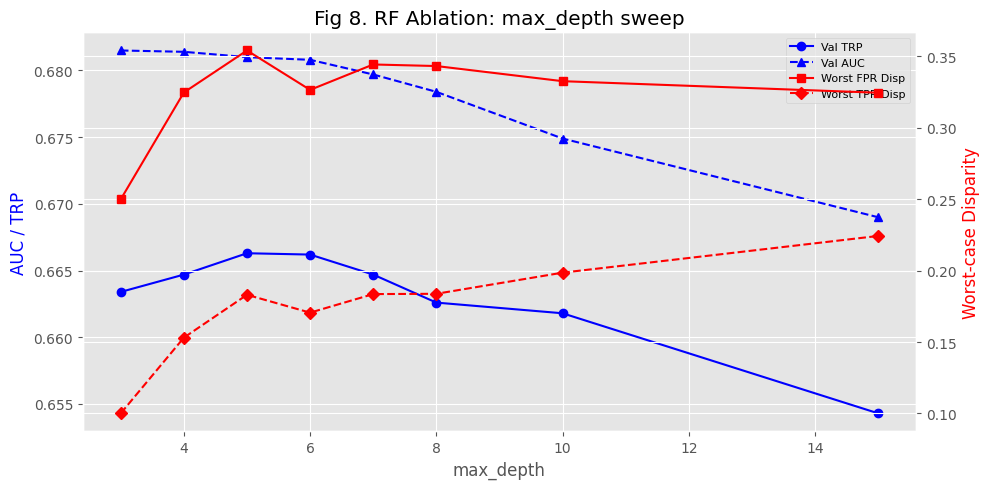

In [44]:
# Figs 6-8: Ablation plots (dual-axis: AUC+TRP left, fairness disparities right)
def plot_ablation(df_ab, param_col, title, fname, log_x=False):
    fig, ax1 = plt.subplots(figsize=(10,5)); ax2 = ax1.twinx()
    x = df_ab[param_col]
    ax1.plot(x, df_ab['Val TRP'], 'b-o', label='Val TRP')
    ax1.plot(x, df_ab['Val AUC'], 'b--^', label='Val AUC')
    ax2.plot(x, df_ab['Worst FPR'], 'r-s', label='Worst FPR Disp')
    ax2.plot(x, df_ab['Worst TPR'], 'r--D', label='Worst TPR Disp')
    if log_x: ax1.set_xscale('log')
    ax1.set_xlabel(param_col); ax1.set_ylabel('AUC / TRP', color='blue')
    ax2.set_ylabel('Worst-case Disparity', color='red')
    ax1.set_title(title)
    h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, fontsize=8)
    plt.tight_layout(); plt.savefig(f'/content/{fname}',dpi=150); plt.show()

plot_ablation(df_ablation_lr,  'C',          'Fig 6. LR Ablation: C sweep',             'fig6_ablation_lr.png',  log_x=True)
plot_ablation(df_ablation_xgb, 'subsample',  'Fig 7. XGB Ablation: subsample sweep',    'fig7_ablation_xgb.png')
plot_ablation(df_ablation_rf,  'max_depth',  'Fig 8. RF Ablation: max_depth sweep',     'fig8_ablation_rf.png')